<a href="https://colab.research.google.com/github/Fugant1/OPERA/blob/main/ser_grpo_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cloud Connection
Drive

In [1]:
from pathlib import Path

In [2]:
def mount_drive():
    """Mount Google Drive in Colab."""
    from google.colab import drive
    drive.mount("/content/drive")

In [3]:
mount_drive()

Mounted at /content/drive


# Get Audio Data
MELD

## Raw

In [4]:
from pathlib import Path
import os
import subprocess
import time
import pandas as pd

In [5]:

DRIVE_ARCHIVE = Path("/content/drive/MyDrive/SER_DPO/MELD/MELD.tar")
MELD_DIR = Path("/content/MELD")
TRAIN_DIR = MELD_DIR / "preprocessed_train_splits"

In [6]:
def extract_tar(archive_path: Path, destination: Path):
    """Extract a .tar archive to destination."""
    archive_path = Path(archive_path)
    destination = Path(destination)

    if not archive_path.exists():
        raise FileNotFoundError(f"Archive not found: {archive_path}")

    destination.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {archive_path.name} → {destination}")
    start = time.time()

    subprocess.run(
        ["tar", "-xf", str(archive_path), "-C", str(destination)],
        check=True,
    )

    elapsed = time.time() - start
    print(f"Extraction completed in {elapsed:.1f}s")

In [7]:

def dataset_info(path: Path):
    """Print basic information about an extracted dataset."""
    path = Path(path)

    n_files = sum(1 for p in path.rglob("*") if p.is_file())

    size = subprocess.run(
        ["du", "-sh", str(path)],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.split()[0]

    print(f"Files: {n_files:,}")
    print(f"Size:  {size}")

In [8]:
def find_file(root: Path, pattern: str) -> Path:
    """Find the first file matching a pattern."""
    matches = list(Path(root).rglob(pattern))

    if not matches:
        raise FileNotFoundError(
            f"Could not find '{pattern}' under {root}"
        )

    return matches[0]


In [9]:
def load_meld_split(split_dir: Path, split: str = "train") -> pd.DataFrame:
    """
    Load a MELD split and resolve audio paths.

    Expected files:
        {split}_preprocessed.csv
        {split}_sent_emo.csv
        *.wav
    """
    split_dir = Path(split_dir)

    audio_files = list(split_dir.rglob("*.wav"))

    preprocessed_csv = find_file(
        split_dir,
        f"{split}_preprocessed.csv",
    )

    emotion_csv = find_file(
        split_dir,
        f"{split}_sent_emo.csv",
    )

    df = pd.read_csv(preprocessed_csv)
    df_emo = pd.read_csv(emotion_csv)

    # Resolve audio filenames → absolute paths
    audio_map = {
        path.name: str(path.resolve())
        for path in audio_files
    }

    df["audio_path"] = (
        df["audio_path"]
        .astype(str)
        .map(lambda x: Path(x).name)
        .map(audio_map)
    )

    # Normalize merge keys
    df["dialogue"] = df["dialogue"].astype(int)
    df["utterance"] = df["utterance"].astype(int)

    df_emo["Dialogue_ID"] = df_emo["Dialogue_ID"].astype(int)
    df_emo["Utterance_ID"] = df_emo["Utterance_ID"].astype(int)

    # Add MELD metadata
    df = df.merge(
        df_emo[
            [
                "Dialogue_ID",
                "Utterance_ID",
                "Emotion",
                "Utterance",
                "Speaker",
            ]
        ],
        left_on=["dialogue", "utterance"],
        right_on=["Dialogue_ID", "Utterance_ID"],
        how="left",
    )

    df = (
        df.drop(columns=["Dialogue_ID", "Utterance_ID"])
          .rename(
              columns={
                  "Utterance": "text",
                  "Emotion": "emotion",
                  "Speaker": "speaker",
              }
          )
    )

    # Validation
    missing_audio = df["audio_path"].isna().sum()
    missing_emotion = df["emotion"].isna().sum()

    print(f"Loaded {len(df):,} samples")
    print(
        f"Audio matched: "
        f"{len(df) - missing_audio:,}/{len(df):,}"
    )

    if missing_audio:
        print(f"Warning: {missing_audio:,} audio files missing")

    print(
        f"Metadata matched: "
        f"{len(df) - missing_emotion:,}/{len(df):,}"
    )

    if missing_emotion:
        print(f"Warning: {missing_emotion:,} metadata rows missing")

    return df

In [10]:
def load_meld(
    archive_path: Path = DRIVE_ARCHIVE,
    destination: Path = MELD_DIR,
    split: str = "train",
) -> pd.DataFrame:
    """Download/extract and load a MELD split."""

    if not destination.exists():
        extract_tar(archive_path, destination)
    else:
        print(f"Dataset already exists: {destination}")

    dataset_info(destination)

    split_dir = destination / f"preprocessed_{split}_splits"

    if not split_dir.exists():
        raise FileNotFoundError(
            f"Split directory not found: {split_dir}"
        )

    return load_meld_split(split_dir, split)

In [11]:
raw_train_set = load_meld(
      archive_path=DRIVE_ARCHIVE,
      destination=MELD_DIR,
      split="train",
  )
raw_train_set = pd.read_csv("/content/drive/MyDrive/SER_DPO/raw_train_set.csv")
train_set = raw_train_set

Extracting MELD.tar → /content/MELD
Extraction completed in 38.5s
Files: 13,853
Size:  1.4G
Loaded 9,988 samples
Audio matched: 9,988/9,988
Metadata matched: 9,988/9,988


In [12]:
display(raw_train_set.head())

,audio_path,time,utterance,dialogue,emotion,text,speaker,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,loudness_sma3_percentile50.0,VoicedSegmentsPerSec,hammarbergIndexV_sma3nz_amean,HNRdBACF_sma3nz_amean,jitterLocal_sma3nz_amean,shimmerLocaldB_sma3nz_amean
0,/content/MELD/preprocessed_train_splits/dia0_u...,5.675,0,0,neutral,also I was the point person on my companys tr...,Chandler,26.082579,3.457907,0.903027,2.852050,14.535190,3.502117,0.013262,1.145115
1,/content/MELD/preprocessed_train_splits/dia0_u...,1.472,1,0,neutral,You mustve had your hands full.,The Interviewer,27.179947,7.154980,0.786694,2.836879,23.540230,4.868654,0.018297,1.263287
2,/content/MELD/preprocessed_train_splits/dia0_u...,2.944,2,0,neutral,That I did. That I did.,Chandler,24.832411,0.999050,0.510710,2.083333,15.932747,3.059079,0.018017,1.611432
3,/content/MELD/preprocessed_train_splits/dia0_u...,2.773,3,0,neutral,So lets talk a little bit about your duties.,The Interviewer,31.246944,8.833487,0.664609,3.690037,17.701504,4.495695,0.019034,1.525157
4,/content/MELD/preprocessed_train_splits/dia0_u...,6.485,4,0,surprise,My duties? All right.,Chandler,35.731873,17.373041,1.231185,2.336449,11.918805,1.458148,0.029392,1.673089


In [13]:
raw_train_set['emotion'].value_counts()

,count
emotion,
neutral,4709
joy,1743
surprise,1205
anger,1109
sadness,683
disgust,271
fear,268


In [14]:
raw_train_set['speaker'].value_counts()

,count
speaker,
Joey,1509
Ross,1458
Rachel,1435
Phoebe,1321
Monica,1299
...,...
Mrs. Chatracus,1
Doctor,1
Burt,1


## Acoustic Cues Analysis (Raw Train Set)

In [15]:
# ==============================================================================
# Extração / Carregamento dos Cues Acústicos (eGeMAPSv02) no Raw Train Set
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import sys
import subprocess
from pathlib import Path
from typing import Dict, List, Any
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Mapeamento dos descritores do Acoustic Inventory para variáveis físicas do eGeMAPS
ACOUSTIC_CUES = {
    "Pitch Height (st)": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "Pitch Dynamics (st)": "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2",
    "Vocal Energy (Sones)": "loudness_sma3_percentile50.0",
    "Speaking Rate (seg/s)": "VoicedSegmentsPerSec",
    "Spectral Tilt (dB)": "hammarbergIndexV_sma3nz_amean",
    "HNR (dB)": "HNRdBACF_sma3nz_amean",
    "Jitter Local": "jitterLocal_sma3nz_amean",
    "Shimmer Local (dB)": "shimmerLocaldB_sma3nz_amean",
}

target_features = list(ACOUSTIC_CUES.values())
missing_features = [col for col in target_features if col not in raw_train_set.columns]

if missing_features:
    cache_path = Path("/content/train_egemaps_features.csv")
    alt_cache_path = Path("/content/raw_train_egemaps_features.csv")
    active_cache = cache_path if cache_path.exists() else (alt_cache_path if alt_cache_path.exists() else None)

    if active_cache is not None:
        print(f"📁 Carregando features eGeMAPSv02 cacheadas de {active_cache}...")
        df_cached = pd.read_csv(active_cache)
        if "audio_path" in df_cached.columns:
            cols_to_merge = ["audio_path"] + [c for c in target_features if c in df_cached.columns and c not in raw_train_set.columns]
            raw_train_set = raw_train_set.merge(df_cached[cols_to_merge].drop_duplicates(subset=["audio_path"]), on="audio_path", how="left")
        else:
            cols_to_add = [c for c in missing_features if c in df_cached.columns]
            raw_train_set = pd.concat([raw_train_set.reset_index(drop=True), df_cached[cols_to_add].reset_index(drop=True)], axis=1)
    else:
        print("🎙️ Extraindo features acústicas eGeMAPSv02 via openSMILE no raw train set...")
        try:
            import opensmile
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opensmile"], check=True)
            import opensmile

        smile = opensmile.Smile(
            feature_set=opensmile.FeatureSet.eGeMAPSv02,
            feature_level=opensmile.FeatureLevel.Functionals,
        )

        extracted_records = []
        valid_indices = []
        for idx, row in tqdm(raw_train_set.iterrows(), total=len(raw_train_set), desc="Processando Áudios (Raw Train)"):
            p = Path(str(row["audio_path"]))
            if p.is_file():
                try:
                    feat = smile.process_file(str(p))
                    extracted_records.append(feat.iloc[0].to_dict())
                    valid_indices.append(idx)
                except Exception:
                    pass

        if extracted_records:
            df_feats = pd.DataFrame(extracted_records, index=valid_indices)
            for c in target_features:
                if c in df_feats.columns:
                    raw_train_set.loc[valid_indices, c] = df_feats[c]

            try:
                df_feats["audio_path"] = raw_train_set.loc[valid_indices, "audio_path"].values
                df_feats.to_csv(cache_path, index=False)
                df_feats.to_csv(alt_cache_path, index=False)
                print(f"✅ Cache salvo em {cache_path}")
            except Exception as e:
                print(f"Aviso ao salvar cache: {e}")
        else:
            print("⚠️ Arquivos de áudio não encontrados para extração imediata. Verifique se o MELD.tar foi extraído.")

train_set = raw_train_set

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

def analyze_speaker_quantile_validity(df: pd.DataFrame, min_utterances_threshold: int = 8):
    # Detecta coluna de emoção
    label_col = "emotion" if "emotion" in df.columns else ("label" if "label" in df.columns else None)
    if label_col is None:
        raise ValueError("Coluna de emoção ('emotion' ou 'label') não encontrada no DataFrame.")

    total_samples = len(df)
    spk_counts = df['speaker'].value_counts()
    num_unique_speakers = len(spk_counts)

    print("=" * 80)
    print(f"📊 DIAGNÓSTICO DE VALIDADE DOS QUANTIS POR LOCUTOR (Total: {total_samples} amostras)")
    print("=" * 80)

    # ---------------------------------------------------------
    # 1. ANÁLISE DE VOLUME / CAUDA LONGA (Utterances por Speaker)
    # ---------------------------------------------------------
    bins = [0, 1, 3, 7, 20, np.inf]
    bin_labels = [
        "1 fala (100% degenerado)",
        "2 a 3 falas (Crítico)",
        f"4 a {min_utterances_threshold - 1} falas (Abaixo do threshold)",
        f"{min_utterances_threshold} a 20 falas (Limítrofe)",
        "> 20 falas (Estatisticamente estável)"
    ]

    binned_speakers = pd.cut(spk_counts, bins=bins, labels=bin_labels)
    spk_dist = pd.DataFrame({
        "Qtd Falantes": binned_speakers.value_counts(sort=False),
        "% dos Falantes": (binned_speakers.value_counts(sort=False, normalize=True) * 100).round(2),
    })

    # Calcula quantas falas totais do dataset caem em cada balde
    utterance_sums = []
    for interval_label in bin_labels:
        matching_spks = spk_counts[binned_speakers == interval_label].index
        utterance_sums.append(df[df['speaker'].isin(matching_spks)].shape[0])

    spk_dist["Falas Afetadas"] = utterance_sums
    spk_dist["% do Corpus Total"] = ((spk_dist["Falas Afetadas"] / total_samples) * 100).round(2)

    print("\n1️⃣ DISTRIBUIÇÃO DE FALAS E COBERTURA DE LOCUTORES:")
    display(spk_dist)

    speakers_below_threshold = (spk_counts < min_utterances_threshold).sum()
    pct_fallback = (df['speaker'].isin(spk_counts[spk_counts < min_utterances_threshold].index).sum() / total_samples) * 100

    print(f"• Total de locutores únicos: {num_unique_speakers}")
    print(f"• Locutores com menos de {min_utterances_threshold} falas: {speakers_below_threshold} ({speakers_below_threshold / num_unique_speakers * 100:.1f}%)")
    print(f"• Impacto no dataset: {pct_fallback:.2f}% de todas as falas caem no Fallback Global (__GLOBAL__).")

    # ---------------------------------------------------------
    # 2. ANÁLISE DE DIVERSIDADE EMOCIONAL (Viés de Amostragem)
    # ---------------------------------------------------------
    # Para falantes com >= min_utterances_threshold, calcula se o perfil está enviesado
    eligible_speakers = spk_counts[spk_counts >= min_utterances_threshold].index
    num_classes = df[label_col].nunique()
    max_entropy = np.log2(num_classes)  # Entropia máxima teórica (uniforme)

    diversity_records = []
    for spk in spk_counts.index:
        sub = df[df['speaker'] == spk]
        counts = sub[label_col].value_counts()
        probs = counts / len(sub)

        # Entropia normalizada [0.0 = mono-emoção, 1.0 = perfeitamente balanceado]
        shannon_ent = entropy(probs, base=2) / max_entropy if max_entropy > 0 else 0.0
        dominant_emo = counts.index[0]
        dominant_pct = (counts.iloc[0] / len(sub)) * 100

        diversity_records.append({
            "speaker": spk,
            "total_utterances": len(sub),
            "dominant_emotion": dominant_emo,
            "dominant_pct": round(dominant_pct, 1),
            "normalized_entropy": round(shannon_ent, 3),
            "status_calibracao": "Individual" if len(sub) >= min_utterances_threshold else "Fallback Global"
        })

    df_div = pd.DataFrame(diversity_records)

    # Locutores 'elegíveis' mas com forte skew emocional (ex: > 60% uma única emoção)
    skewed_calibrated = df_div[(df_div["status_calibracao"] == "Individual") & (df_div["dominant_pct"] >= 60.0)]

    print("\n" + "-" * 80)
    print("2️⃣ ANÁLISE DE VIÉS EMOCIONAL NOS LOCUTORES CALIBRADOS:")
    print(f"• Locutores calibrados individualmente: {len(eligible_speakers)}")
    print(f"• Locutores calibrados com SEVERO VIÉS emocional (>= 60% em uma única emoção): {len(skewed_calibrated)}")

    if len(skewed_calibrated) > 0:
        print("\n⚠️ ALERTA: Locutores calibrados com viés (seus quantis refletem a emoção dominante, não a voz neutra):")
        display(skewed_calibrated.sort_values(by="total_utterances", ascending=False).head(10))

    # ---------------------------------------------------------
    # 3. VERIFICAÇÃO DE COLAPSO DA FAIXA MODERADA (Se houver eGeMAPS)
    # ---------------------------------------------------------
    if "F0semitoneFrom27.5Hz_sma3nz_amean" in df.columns:
        print("\n" + "-" * 80)
        print("3️⃣ VERIFICAÇÃO DE COLAPSO DE QUANTIS (Largura da Faixa Moderada em Pitch):")
        f0_col = "F0semitoneFrom27.5Hz_sma3nz_amean"

        iqr_records = []
        for spk in eligible_speakers[:15]:  # Primeiros 15
            sub_f0 = df[df['speaker'] == spk][f0_col]
            q33 = sub_f0.quantile(0.33)
            q66 = sub_f0.quantile(0.66)
            band_width = q66 - q33  # Largura da faixa considerada 'moderate'

            iqr_records.append({
                "speaker": spk,
                "n_utterances": len(sub_f0),
                "Q33_semitones": round(q33, 2),
                "Q66_semitones": round(q66, 2),
                "Bandwidth_Moderate": round(band_width, 2),
                "Bandwidth_Colapsada": "SIM (Muito Estreita)" if band_width < 1.0 else "NÃO (Saudável)"
            })
        display(pd.DataFrame(iqr_records))

    print("=" * 80)
    return df_div

# Executa o diagnóstico sobre o raw_train_set
df_speaker_analysis = analyze_speaker_quantile_validity(raw_train_set, min_utterances_threshold=8)

📊 DIAGNÓSTICO DE VALIDADE DOS QUANTIS POR LOCUTOR (Total: 9988 amostras)

1️⃣ DISTRIBUIÇÃO DE FALAS E COBERTURA DE LOCUTORES:


,Qtd Falantes,% dos Falantes,Falas Afetadas,% do Corpus Total
count,,,,
1 fala (100% degenerado),66,25.38,66,0.66
2 a 3 falas (Crítico),62,23.85,147,1.47
4 a 7 falas (Abaixo do threshold),53,20.38,264,2.64
8 a 20 falas (Limítrofe),56,21.54,654,6.55
> 20 falas (Estatisticamente estável),23,8.85,8857,88.68


• Total de locutores únicos: 260
• Locutores com menos de 8 falas: 181 (69.6%)
• Impacto no dataset: 4.78% de todas as falas caem no Fallback Global (__GLOBAL__).

--------------------------------------------------------------------------------
2️⃣ ANÁLISE DE VIÉS EMOCIONAL NOS LOCUTORES CALIBRADOS:
• Locutores calibrados individualmente: 79
• Locutores calibrados com SEVERO VIÉS emocional (>= 60% em uma única emoção): 32

⚠️ ALERTA: Locutores calibrados com viés (seus quantis refletem a emoção dominante, não a voz neutra):


,speaker,total_utterances,dominant_emotion,dominant_pct,normalized_entropy,status_calibracao
11,Doug,35,joy,68.6,0.320,Individual
15,Pete,30,neutral,66.7,0.537,Individual
24,Phoebe Sr,18,neutral,61.1,0.463,Individual
26,Susan,18,neutral,61.1,0.534,Individual
27,Dr. Green,18,anger,77.8,0.336,Individual
32,Chip,17,neutral,76.5,0.348,Individual
35,Mr. Tribbiani,13,neutral,69.2,0.406,Individual
38,Kristen,13,neutral,76.9,0.353,Individual
40,Joshua,13,neutral,84.6,0.275,Individual
43,Russell,12,neutral,91.7,0.147,Individual



--------------------------------------------------------------------------------
3️⃣ VERIFICAÇÃO DE COLAPSO DE QUANTIS (Largura da Faixa Moderada em Pitch):


,speaker,n_utterances,Q33_semitones,Q66_semitones,Bandwidth_Moderate,Bandwidth_Colapsada
0,Joey,1509,28.52,33.47,4.95,NÃO (Saudável)
1,Ross,1458,31.85,35.55,3.70,NÃO (Saudável)
2,Rachel,1435,38.54,43.12,4.58,NÃO (Saudável)
3,Phoebe,1321,38.35,42.79,4.44,NÃO (Saudável)
4,Monica,1299,37.51,41.73,4.22,NÃO (Saudável)
5,Chandler,1283,30.94,35.09,4.15,NÃO (Saudável)
6,Janice,58,37.35,41.25,3.90,NÃO (Saudável)
7,Carol,46,36.36,39.79,3.42,NÃO (Saudável)
8,Emily,43,36.36,38.76,2.40,NÃO (Saudável)
9,Tag,41,27.30,31.59,4.29,NÃO (Saudável)


📊 DIAGNÓSTICO ACÚSTICO: VARIAÇÃO POR EMOÇÃO, QUANTIS E AMPLITUDES (LOCUTORES VS GLOBAL)

1️⃣ QUANTIS E AMPLITUDE GLOBAL POR CUE ACÚSTICO (CORPUS COMPLETO):


,Min,Q25,Q33,Median (Q50),Q66,Q75,Max,Global Amplitude,Global IQR,Mean Speaker Amp,Speaker/Global Amp (%)
Metric,,,,,,,,,,,
Pitch Height (st),0.00,31.82,33.42,36.41,39.15,40.90,60.82,60.82,9.08,41.07,67.5
Pitch Dynamics (st),0.00,3.48,4.12,5.47,6.95,8.17,38.29,38.29,4.69,25.35,66.2
Vocal Energy (Sones),0.06,0.67,0.76,0.94,1.12,1.24,3.70,3.64,0.57,2.19,60.1
Speaking Rate (seg/s),0.00,1.91,2.13,2.53,2.93,3.20,25.00,25.00,1.29,11.84,47.3
Spectral Tilt (dB),-19.85,14.12,15.29,17.31,19.12,20.28,41.76,61.61,6.15,28.71,46.6
HNR (dB),-8.41,4.74,5.27,6.18,7.01,7.54,13.86,22.27,2.80,11.35,51.0
Jitter Local,0.00,0.02,0.02,0.02,0.03,0.03,0.25,0.25,0.01,0.09,35.2
Shimmer Local (dB),0.00,1.03,1.07,1.16,1.25,1.31,5.99,5.99,0.28,2.42,40.4



2️⃣ VARIAÇÃO DE EMOÇÕES NOS QUANTIS E AMPLITUDES DOS CUES ACÚSTICOS:


,Emotion,Metric,Utterances,Mean,Std,Min,Q25,Q33,Median (Q50),Q66,Q75,Max,Amplitude,IQR
0,anger,Pitch Height (st),1109,38.60,7.97,0.00,34.78,36.56,39.33,41.94,43.86,57.43,57.43,9.09
1,anger,Pitch Dynamics (st),1109,6.56,3.94,0.00,4.04,4.69,5.87,7.24,8.14,28.78,28.78,4.10
2,anger,Vocal Energy (Sones),1109,1.11,0.45,0.06,0.81,0.90,1.08,1.25,1.36,3.49,3.42,0.55
3,anger,Speaking Rate (seg/s),1109,2.78,1.32,0.00,2.08,2.30,2.69,3.12,3.38,20.00,20.00,1.30
4,anger,Spectral Tilt (dB),1109,15.64,4.90,-4.99,12.77,13.80,15.76,17.67,18.79,33.29,38.28,6.02
5,anger,HNR (dB),1109,6.32,2.08,-0.79,5.13,5.63,6.44,7.21,7.68,13.58,14.37,2.55
6,anger,Jitter Local,1109,0.02,0.01,0.00,0.02,0.02,0.02,0.03,0.03,0.16,0.16,0.01
7,anger,Shimmer Local (dB),1109,1.16,0.30,0.00,1.02,1.07,1.16,1.24,1.30,3.27,3.27,0.28
8,disgust,Pitch Height (st),271,36.61,7.58,0.00,32.42,34.07,37.07,39.91,41.74,54.48,54.48,9.33
9,disgust,Pitch Dynamics (st),271,6.66,4.21,0.00,4.06,4.58,5.77,7.20,8.24,29.22,29.22,4.18



3️⃣ AMPLITUDES ABSOLUTAS (MAX - MIN) DOS 20 LOCUTORES COM MAIS FALAS:


,Utterances,Pitch Height (st),Pitch Dynamics (st),Vocal Energy (Sones),Speaking Rate (seg/s),Spectral Tilt (dB),HNR (dB),Jitter Local,Shimmer Local (dB)
Speaker,,,,,,,,,
Joey,1509,56.58,37.57,3.42,20.00,46.75,22.20,0.12,3.93
Ross,1458,51.61,31.56,2.92,20.00,38.44,15.22,0.25,3.59
Rachel,1435,57.05,38.29,2.99,20.00,38.45,16.15,0.18,5.34
Phoebe,1321,58.77,35.45,3.36,25.00,40.74,14.84,0.15,3.88
Monica,1299,57.78,32.79,2.62,25.00,38.08,16.05,0.16,5.99
Chandler,1283,58.73,36.47,3.11,20.00,55.80,21.98,0.08,4.62
Janice,58,20.71,21.28,2.19,3.20,25.98,6.66,0.09,0.85
Carol,46,22.84,13.42,1.94,7.04,19.96,9.06,0.04,0.70
Emily,43,48.96,15.95,1.80,20.00,27.71,9.76,0.05,1.93



4️⃣ COBERTURA DA AMPLITUDE GLOBAL (%) PELOS 20 LOCUTORES COM MAIS FALAS:


,Pitch Height (st),Pitch Dynamics (st),Vocal Energy (Sones),Speaking Rate (seg/s),Spectral Tilt (dB),HNR (dB),Jitter Local,Shimmer Local (dB)
Speaker,,,,,,,,
Joey (n=1509),93.0,98.1,94.1,80.0,75.9,99.7,47.7,65.6
Ross (n=1458),84.9,82.4,80.3,80.0,62.4,68.3,100.0,60.0
Rachel (n=1435),93.8,100.0,82.1,80.0,62.4,72.5,69.9,89.2
Phoebe (n=1321),96.6,92.6,92.4,100.0,66.1,66.6,58.1,64.7
Monica (n=1299),95.0,85.6,72.1,100.0,61.8,72.1,64.9,100.0
Chandler (n=1283),96.6,95.2,85.4,80.0,90.6,98.7,33.4,77.1
Janice (n=58),34.1,55.6,60.1,12.8,42.2,29.9,34.3,14.1
Carol (n=46),37.6,35.1,53.4,28.2,32.4,40.7,16.6,11.6
Emily (n=43),80.5,41.6,49.4,80.0,45.0,43.8,18.1,32.2



📈 GERANDO VISUALIZAÇÕES DOS QUANTIS E AMPLITUDES...


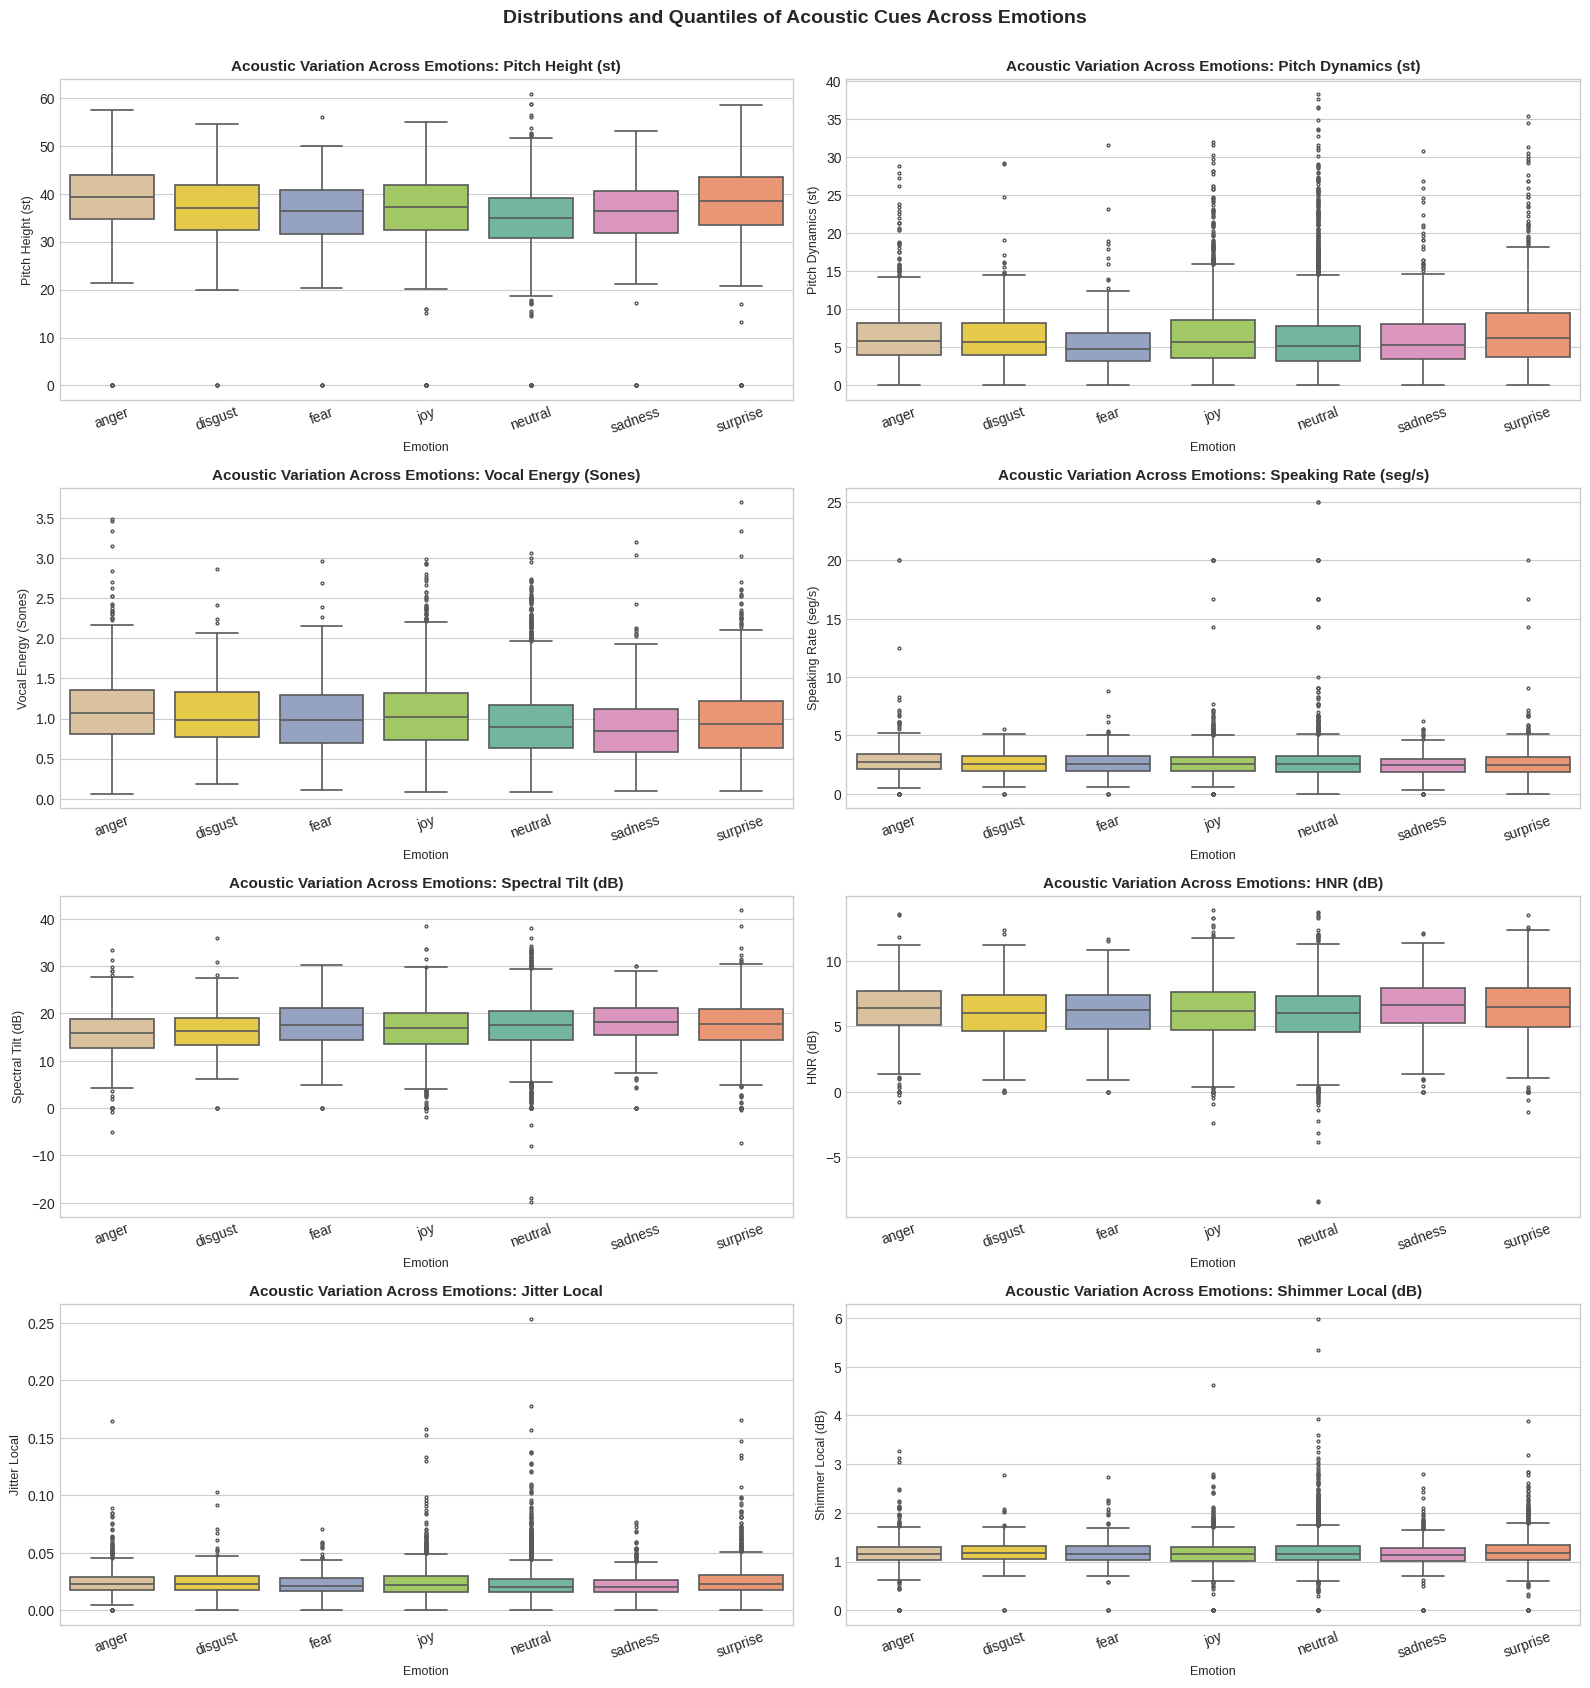

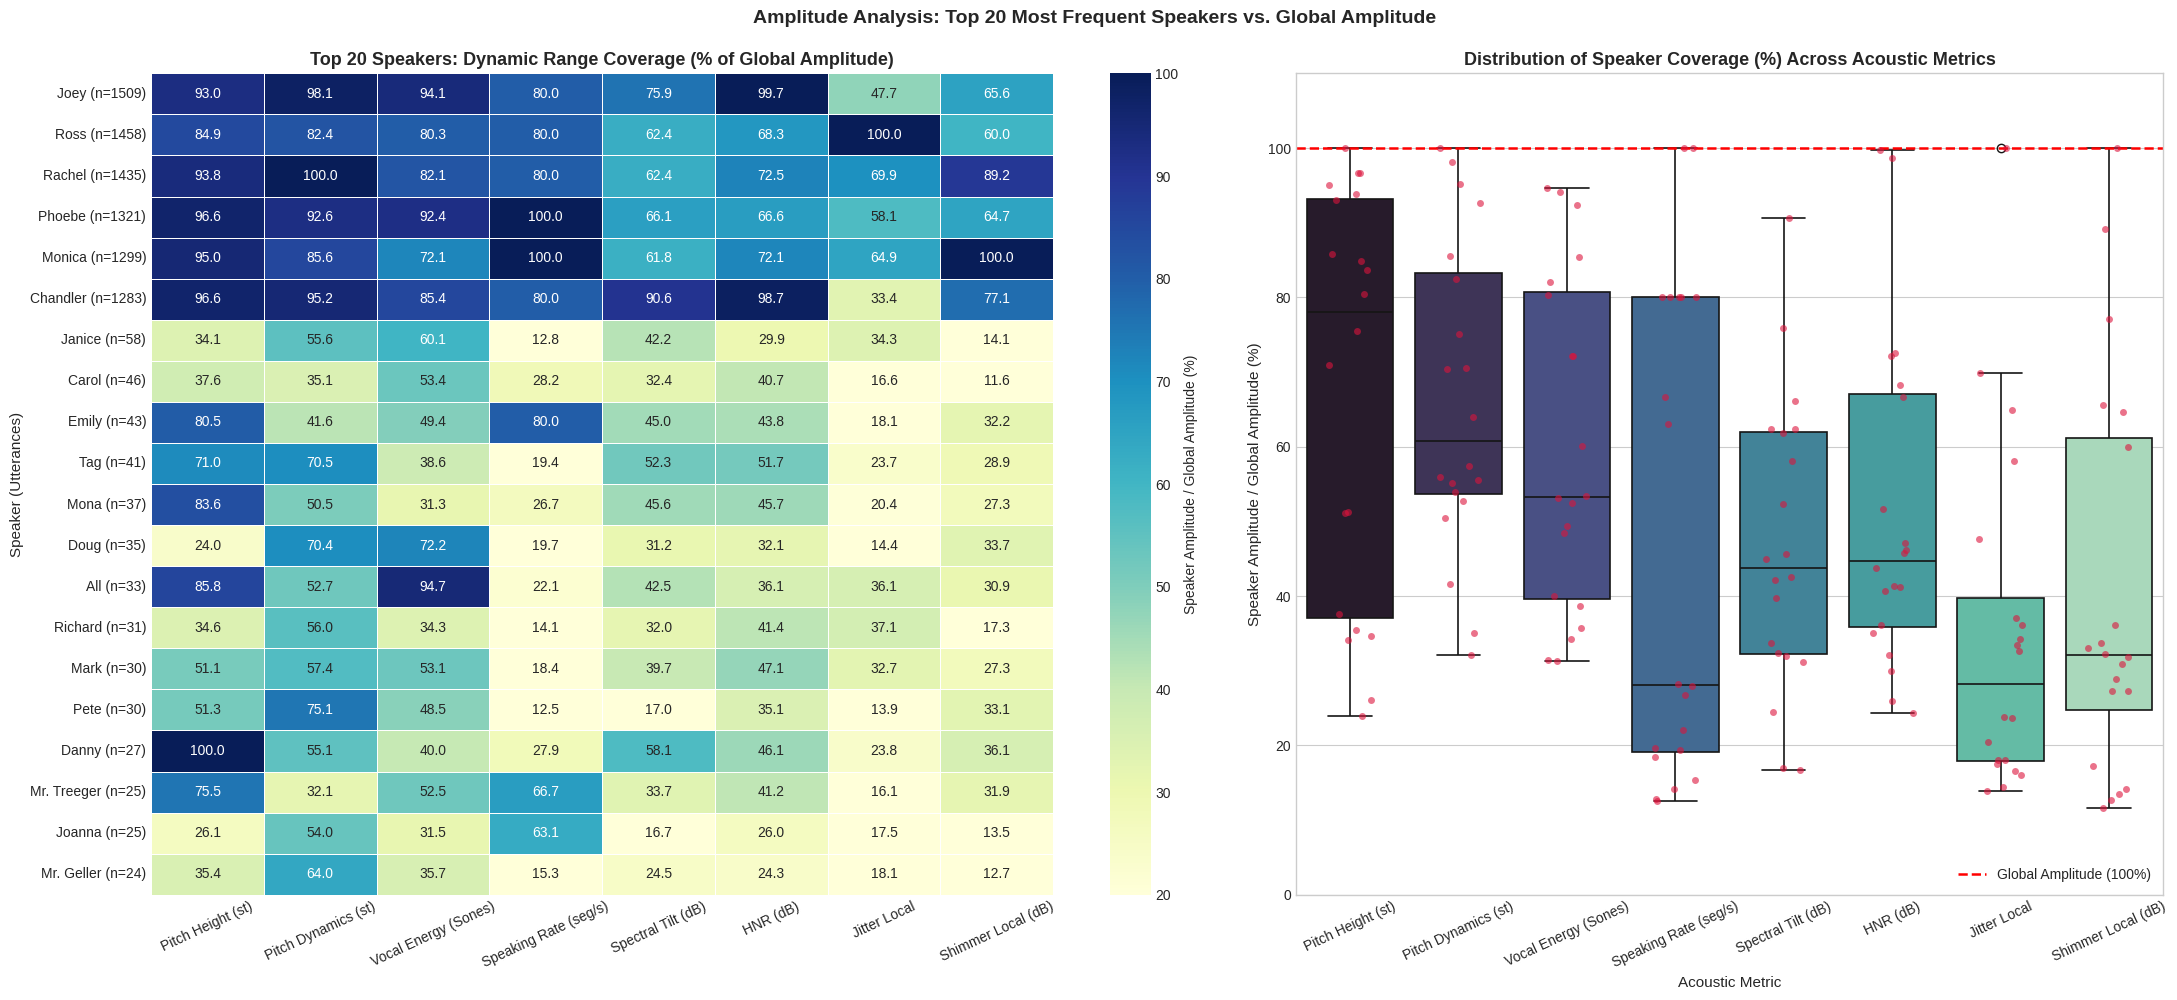

In [17]:
# ==============================================================================
# Diagnóstico de Variação por Emoção e Amplitudes dos Locutores (Raw Train Set)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_emotion_and_speaker_acoustics(
    df: pd.DataFrame,
    top_n_speakers: int = 20,
    cues_dict: Dict[str, str] = ACOUSTIC_CUES,
):
    active_cues = {label: col for label, col in cues_dict.items() if col in df.columns}
    if not active_cues:
        print("⚠️ Nenhuma das colunas de cues acústicos foi encontrada no DataFrame.")
        return

    print("=" * 90)
    print("📊 DIAGNÓSTICO ACÚSTICO: VARIAÇÃO POR EMOÇÃO, QUANTIS E AMPLITUDES (LOCUTORES VS GLOBAL)")
    print("=" * 90)

    # A. AMPLITUDE E QUANTIS GLOBAIS (Full Corpus)
    global_rows = []
    global_amps = {}
    for label, col in active_cues.items():
        s = df[col].dropna()
        q10, q25, q33, q50, q66, q75, q90 = s.quantile([0.10, 0.25, 0.33, 0.50, 0.66, 0.75, 0.90])
        min_v, max_v = s.min(), s.max()
        amp = max_v - min_v
        global_amps[label] = amp
        global_rows.append({
            "Metric": label,
            "Count": len(s),
            "Mean": round(s.mean(), 2),
            "Std": round(s.std(), 2),
            "Min": round(min_v, 2),
            "Q10": round(q10, 2),
            "Q25": round(q25, 2),
            "Q33": round(q33, 2),
            "Median (Q50)": round(q50, 2),
            "Q66": round(q66, 2),
            "Q75": round(q75, 2),
            "Q90": round(q90, 2),
            "Max": round(max_v, 2),
            "Global Amplitude": round(amp, 2),
            "Global IQR": round(q75 - q25, 2),
        })

    df_global = pd.DataFrame(global_rows).set_index("Metric")

    # B. VARIAÇÃO DE EMOÇÃO E NÚMEROS DOS CUES ACÚSTICOS EM QUANTIS
    emo_rows = []
    for emo, emo_df in df.groupby("emotion"):
        for label, col in active_cues.items():
            s = emo_df[col].dropna()
            if len(s) == 0:
                continue
            q10, q25, q33, q50, q66, q75, q90 = s.quantile([0.10, 0.25, 0.33, 0.50, 0.66, 0.75, 0.90])
            min_v, max_v = s.min(), s.max()
            emo_rows.append({
                "Emotion": emo,
                "Metric": label,
                "Utterances": len(s),
                "Mean": round(s.mean(), 2),
                "Std": round(s.std(), 2),
                "Min": round(min_v, 2),
                "Q25": round(q25, 2),
                "Q33": round(q33, 2),
                "Median (Q50)": round(q50, 2),
                "Q66": round(q66, 2),
                "Q75": round(q75, 2),
                "Max": round(max_v, 2),
                "Amplitude": round(max_v - min_v, 2),
                "IQR": round(q75 - q25, 2),
            })

    df_emotion_quantiles = pd.DataFrame(emo_rows)

    # C. AMPLITUDE DOS 20 LOCUTORES COM MAIS FALAS (TOP 20 UTTERANCE SPEAKERS)
    spk_counts = df["speaker"].value_counts()
    top_speakers = spk_counts.head(top_n_speakers).index.tolist()

    spk_amp_rows = []
    spk_ratio_rows = []

    for spk in top_speakers:
        sub = df[df["speaker"] == spk]
        n_utt = len(sub)
        amp_entry = {"Speaker": spk, "Utterances": n_utt}
        ratio_entry = {"Speaker": f"{spk} (n={n_utt})"}

        for label, col in active_cues.items():
            s = sub[col].dropna()
            g_amp = global_amps.get(label, 0)
            if len(s) > 1:
                s_amp = s.max() - s.min()
                amp_entry[label] = round(s_amp, 2)
                ratio_entry[label] = round((s_amp / g_amp) * 100, 1) if g_amp > 0 else 0.0
            else:
                amp_entry[label] = 0.0
                ratio_entry[label] = 0.0

        spk_amp_rows.append(amp_entry)
        spk_ratio_rows.append(ratio_entry)

    df_top20_amplitudes = pd.DataFrame(spk_amp_rows).set_index("Speaker")
    df_top20_relative_amplitudes = pd.DataFrame(spk_ratio_rows).set_index("Speaker")

    # Adiciona estatísticas agregadas dos locutores à tabela global
    metric_cols = [c for c in df_top20_amplitudes.columns if c != "Utterances"]
    df_global["Mean Speaker Amp"] = [
        round(df_top20_amplitudes[m].mean(), 2) for m in df_global.index if m in metric_cols
    ]
    df_global["Speaker/Global Amp (%)"] = [
        round((df_top20_amplitudes[m].mean() / df_global.loc[m, "Global Amplitude"]) * 100, 1)
        for m in df_global.index if m in metric_cols
    ]

    # D. EXIBIÇÃO DE RESULTADOS
    print("\n1️⃣ QUANTIS E AMPLITUDE GLOBAL POR CUE ACÚSTICO (CORPUS COMPLETO):")
    display(df_global[["Min", "Q25", "Q33", "Median (Q50)", "Q66", "Q75", "Max", "Global Amplitude", "Global IQR", "Mean Speaker Amp", "Speaker/Global Amp (%)"]])

    print("\n2️⃣ VARIAÇÃO DE EMOÇÕES NOS QUANTIS E AMPLITUDES DOS CUES ACÚSTICOS:")
    display(df_emotion_quantiles.head(16))

    print(f"\n3️⃣ AMPLITUDES ABSOLUTAS (MAX - MIN) DOS {top_n_speakers} LOCUTORES COM MAIS FALAS:")
    display(df_top20_amplitudes)

    print(f"\n4️⃣ COBERTURA DA AMPLITUDE GLOBAL (%) PELOS {top_n_speakers} LOCUTORES COM MAIS FALAS:")
    display(df_top20_relative_amplitudes)

    # --------------------------------------------------------------------------
    # 4. PLOTS
    # --------------------------------------------------------------------------
    print("\n" + "=" * 90)
    print("📈 GERANDO VISUALIZAÇÕES DOS QUANTIS E AMPLITUDES...")
    print("=" * 90)

    # FIGURA 1: Variação das Emoções por Cue Acústico (Boxplots com Quantis)
    n_cues = len(active_cues)
    cols = 2
    rows = (n_cues + cols - 1) // cols

    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    fig1, axes1 = plt.subplots(rows, cols, figsize=(16, 4.2 * rows))
    axes1 = np.array(axes1).flatten()
    emo_order = sorted(df["emotion"].unique())

    for idx, (label, col) in enumerate(active_cues.items()):
        ax = axes1[idx]
        sns.boxplot(
            data=df,
            x="emotion",
            y=col,
            order=emo_order,
            hue="emotion",
            legend=False,
            palette="Set2",
            ax=ax,
            fliersize=2,
            linewidth=1.2,
        )
        ax.set_title(f"Acoustic Variation Across Emotions: {label}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Emotion", fontsize=9)
        ax.set_ylabel(label, fontsize=9)
        ax.tick_params(axis="x", rotation=20)

    for idx in range(len(active_cues), len(axes1)):
        fig1.delaxes(axes1[idx])

    fig1.suptitle("Distributions and Quantiles of Acoustic Cues Across Emotions", fontsize=14, fontweight="bold", y=1.002)
    plt.tight_layout()
    plt.show()

    # FIGURA 2: Comparação de Amplitude dos Locutores vs Amplitude Global
    fig2, (ax_heat, ax_dist) = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={"width_ratios": [1.3, 1]})

    # Subplot A: Heatmap com percentual de amplitude global coberto
    sns.heatmap(
        df_top20_relative_amplitudes,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar_kws={"label": "Speaker Amplitude / Global Amplitude (%)"},
        vmin=20,
        vmax=100,
        ax=ax_heat,
        linewidths=0.5,
    )
    ax_heat.set_title(f"Top {top_n_speakers} Speakers: Dynamic Range Coverage (% of Global Amplitude)", fontsize=13, fontweight="bold")
    ax_heat.set_ylabel("Speaker (Utterances)", fontsize=11)
    ax_heat.tick_params(axis="x", rotation=25)

    # Subplot B: Distribuição da cobertura relativa por métrica acústica
    df_melted_ratio = df_top20_relative_amplitudes.melt(var_name="Metric", value_name="Relative Amplitude (%)")
    sns.boxplot(
        data=df_melted_ratio,
        x="Metric",
        y="Relative Amplitude (%)",
        hue="Metric",
        legend=False,
        palette="mako",
        ax=ax_dist,
        linewidth=1.2,
    )
    sns.stripplot(
        data=df_melted_ratio,
        x="Metric",
        y="Relative Amplitude (%)",
        color="crimson",
        alpha=0.6,
        jitter=0.2,
        size=5,
        ax=ax_dist,
    )
    ax_dist.axhline(100.0, color="red", linestyle="--", linewidth=1.8, label="Global Amplitude (100%)")
    ax_dist.set_ylim(0, 110)
    ax_dist.set_title("Distribution of Speaker Coverage (%) Across Acoustic Metrics", fontsize=13, fontweight="bold")
    ax_dist.set_xlabel("Acoustic Metric", fontsize=11)
    ax_dist.set_ylabel("Speaker Amplitude / Global Amplitude (%)", fontsize=11)
    ax_dist.tick_params(axis="x", rotation=25)
    ax_dist.legend(loc="lower right", fontsize=10)

    fig2.suptitle(f"Amplitude Analysis: Top {top_n_speakers} Most Frequent Speakers vs. Global Amplitude", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()

    return {
        "global_summary": df_global,
        "emotion_quantiles": df_emotion_quantiles,
        "speaker_amplitudes": df_top20_amplitudes,
        "speaker_relative_amplitudes": df_top20_relative_amplitudes,
    }

# Executa o diagnóstico completo sobre raw_train_set
acoustic_analysis_results = analyze_emotion_and_speaker_acoustics(raw_train_set, top_n_speakers=20)

## Balanced

In [18]:
import pandas as pd
from pathlib import Path
import librosa


def get_audio_duration(audio_path: str) -> float | None:
    """Return audio duration in seconds, or None if the file cannot be read."""
    try:
        return librosa.get_duration(path=audio_path)
    except Exception:
        return None


def sample_balanced_meld(
    df: pd.DataFrame,
    target_total: int = 2000,
    max_neutral_pct: float = 0.15,
    min_duration: float = 0.5,
    max_duration: float = 30.0,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Create a deterministic, emotion-balanced MELD subset.

    Filtering:
        - Removes missing/invalid audio files.
        - Removes audio shorter than min_duration.
        - Removes audio longer than max_duration.

    Balancing:
        - Caps neutral at max_neutral_pct.
        - Distributes remaining samples across non-neutral emotions.
        - Redistributes unused quotas from underrepresented classes.

    Args:
        df: MELD dataframe containing 'audio_path' and 'emotion'.
        target_total: Desired number of samples.
        max_neutral_pct: Maximum proportion of neutral samples.
        min_duration: Minimum audio duration in seconds.
        max_duration: Maximum audio duration in seconds.
        seed: Random seed for deterministic sampling.

    Returns:
        Balanced and filtered DataFrame.
    """

    df = df.copy()

    # ----------------------------------------------------------
    # 1. Deterministic ordering
    # ----------------------------------------------------------

    id_cols = [
        c for c in ["dialogue", "utterance"]
        if c in df.columns
    ]

    if id_cols:
        df = df.sort_values(id_cols)
    elif "audio_path" in df.columns:
        df = df.sort_values("audio_path")

    df = df.reset_index(drop=True)

    # ----------------------------------------------------------
    # 2. Validate audio paths
    # ----------------------------------------------------------

    if "audio_path" not in df.columns:
        raise ValueError("DataFrame must contain 'audio_path'.")

    df = df[
        df["audio_path"].notna()
        & df["audio_path"].apply(
            lambda p: Path(str(p)).is_file()
        )
    ].copy()

    print(f"After audio validation: {len(df):,}")

    # ----------------------------------------------------------
    # 3. Audio duration filtering
    # ----------------------------------------------------------

    print("Computing audio durations...")

    df["duration"] = df["audio_path"].apply(get_audio_duration)

    failed_duration = df["duration"].isna().sum()

    if failed_duration:
        print(
            f"Warning: could not determine duration for "
            f"{failed_duration:,} files."
        )

    df = df[df["duration"].notna()].copy()

    df = df[
        df["duration"].between(
            min_duration,
            max_duration,
            inclusive="both",
        )
    ].copy()

    print(
        f"Duration filter: "
        f"{min_duration:.1f}s–{max_duration:.1f}s"
    )
    print(f"After duration filtering: {len(df):,}")

    # ----------------------------------------------------------
    # 4. Normalize emotion labels
    # ----------------------------------------------------------

    df["emotion"] = (
        df["emotion"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df = df[df["emotion"].ne("nan")].copy()

    emotions = sorted(df["emotion"].unique())

    if not emotions:
        raise ValueError("No valid emotion classes remain.")

    print("\nAvailable emotions:")
    print(emotions)

    # ----------------------------------------------------------
    # 5. Cap neutral
    # ----------------------------------------------------------

    max_neutral_count = int(
        target_total * max_neutral_pct
    )

    non_neutral = [
        emotion
        for emotion in emotions
        if emotion != "neutral"
    ]

    # If neutral is not present, all samples go to
    # non-neutral classes.
    neutral_target = (
        min(
            max_neutral_count,
            len(df[df["emotion"] == "neutral"])
        )
        if "neutral" in emotions
        else 0
    )

    remaining_slots = target_total - neutral_target

    # ----------------------------------------------------------
    # 6. Initial non-neutral quotas
    # ----------------------------------------------------------

    quotas = {}

    if non_neutral:
        base = remaining_slots // len(non_neutral)
        remainder = remaining_slots % len(non_neutral)

        for i, emotion in enumerate(non_neutral):
            quotas[emotion] = (
                base + (1 if i < remainder else 0)
            )

    if "neutral" in emotions:
        quotas["neutral"] = neutral_target

    # ----------------------------------------------------------
    # 7. Redistribute unavailable samples
    # ----------------------------------------------------------

    while True:
        deficit = 0
        saturated = set()

        for emotion, quota in quotas.items():
            available = (
                df["emotion"].eq(emotion).sum()
            )

            if available < quota:
                deficit += quota - available
                quotas[emotion] = available
                saturated.add(emotion)

        if deficit == 0:
            break

        eligible = [
            emotion
            for emotion in non_neutral
            if emotion not in saturated
            and quotas[emotion]
            < df["emotion"].eq(emotion).sum()
        ]

        if not eligible:
            break

        base_extra = deficit // len(eligible)
        remainder = deficit % len(eligible)

        for i, emotion in enumerate(eligible):
            quotas[emotion] += (
                base_extra
                + (1 if i < remainder else 0)
            )

    # ----------------------------------------------------------
    # 8. Deterministic sampling
    # ----------------------------------------------------------

    sampled = []

    for emotion in sorted(quotas):
        n = quotas[emotion]

        if n == 0:
            continue

        class_df = df[df["emotion"] == emotion]

        sampled.append(
            class_df.sample(
                n=n,
                random_state=seed,
                replace=False,
            )
        )

    if not sampled:
        raise ValueError(
            "No samples available after filtering."
        )

    result = pd.concat(
        sampled,
        ignore_index=True,
    )

    # ----------------------------------------------------------
    # 9. Final deterministic ordering
    # ----------------------------------------------------------

    if id_cols:
        result = result.sort_values(id_cols)

    result = result.reset_index(drop=True)

    # ----------------------------------------------------------
    # 10. Diagnostics
    # ----------------------------------------------------------

    print("\n" + "=" * 50)
    print("MELD SAMPLING SUMMARY")
    print("=" * 50)

    print(f"Requested samples: {target_total:,}")
    print(f"Returned samples:  {len(result):,}")

    print("\nEmotion distribution:")
    print(result["emotion"].value_counts())

    print("\nEmotion proportions:")
    print(
        result["emotion"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .astype(str)
        .add("%")
    )

    print("\nAudio duration:")
    print(
        result["duration"].describe()[
            ["min", "mean", "max"]
        ].round(2)
    )

    print("\nQuotas:")
    print(quotas)

    return result

In [19]:
pruned_train_set = sample_balanced_meld(
    raw_train_set,
    target_total=2000,
    max_neutral_pct=0.15,
    min_duration=0.5,
    max_duration=30.0,
    seed=42,
)

run_test = sample_balanced_meld(
    raw_train_set,
    target_total=2000,
    max_neutral_pct=0.15,
    min_duration=0.5,
    max_duration=30.0,
    seed=42,
)

assert pruned_train_set.equals(run_test)

print("\nFinal candidate pool:")
display(pruned_train_set.head())

After audio validation: 9,988
Computing audio durations...
Duration filter: 0.5s–30.0s
After duration filtering: 9,681

Available emotions:
['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

MELD SAMPLING SUMMARY
Requested samples: 2,000
Returned samples:  2,000

Emotion distribution:
emotion
neutral     300
anger       293
joy         292
sadness     291
surprise    291
disgust     268
fear        265
Name: count, dtype: int64

Emotion proportions:
emotion
neutral      15.0%
anger       14.65%
joy          14.6%
sadness     14.55%
surprise    14.55%
disgust      13.4%
fear        13.25%
Name: proportion, dtype: object

Audio duration:
min      0.51
mean     3.33
max     22.95
Name: duration, dtype: float64

Quotas:
{'anger': np.int64(293), 'disgust': np.int64(268), 'fear': np.int64(265), 'joy': np.int64(292), 'sadness': np.int64(291), 'surprise': np.int64(291), 'neutral': 300}
After audio validation: 9,988
Computing audio durations...
Duration filter: 0.5s–30.0s
Af

,audio_path,time,utterance,dialogue,emotion,text,speaker,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,loudness_sma3_percentile50.0,VoicedSegmentsPerSec,hammarbergIndexV_sma3nz_amean,HNRdBACF_sma3nz_amean,jitterLocal_sma3nz_amean,shimmerLocaldB_sma3nz_amean,duration
0,/content/MELD/preprocessed_train_splits/dia0_u...,2.219,9,0,neutral,We can go into detail,The Interviewer,28.810305,2.902483,0.755903,2.803739,19.237234,6.250984,0.015701,1.070284,2.218688
1,/content/MELD/preprocessed_train_splits/dia0_u...,2.005,10,0,fear,No dont I beg of you!,Chandler,33.925426,8.947289,1.143961,2.061856,13.352987,3.297102,0.023200,1.292880,2.005375
2,/content/MELD/preprocessed_train_splits/dia1_u...,2.475,0,1,surprise,But then who? The waitress I went out with las...,Joey,28.792513,1.474661,1.225475,2.489627,18.477812,4.619659,0.012924,1.324144,2.474687
3,/content/MELD/preprocessed_train_splits/dia1_u...,2.219,1,1,sadness,You know? Forget it!,Rachel,37.167171,6.227909,0.617221,1.860465,20.580799,5.719617,0.051611,1.371788,2.218688
4,/content/MELD/preprocessed_train_splits/dia1_u...,4.757,2,1,surprise,"No-no-no-no, no! Who, who were you talking about?",Joey,36.927811,9.820950,1.009611,3.411514,18.723021,4.865646,0.037674,1.331839,4.757375


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
train_set, val_set = train_test_split(
    pruned_train_set,
    test_size=0.2,
    random_state=42,
    stratify=pruned_train_set["emotion"],
)

In [22]:
train_set['emotion'].value_counts()

,count
emotion,
neutral,240
joy,234
anger,234
sadness,233
surprise,233
disgust,214
fear,212


In [23]:
train_set['speaker'].value_counts()

,count
speaker,
Rachel,246
Joey,244
Phoebe,222
Chandler,215
Monica,214
...,...
Rachel and Phoebe,1
Another Scientist,1
Janine,1


In [24]:
display(train_set)

,audio_path,time,utterance,dialogue,emotion,text,speaker,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,loudness_sma3_percentile50.0,VoicedSegmentsPerSec,hammarbergIndexV_sma3nz_amean,HNRdBACF_sma3nz_amean,jitterLocal_sma3nz_amean,shimmerLocaldB_sma3nz_amean,duration
1760,/content/MELD/preprocessed_train_splits/dia921...,0.704,5,921,sadness,No-no its not!,Eric,31.504700,1.594723,0.971907,3.125000,28.355448,8.076351,0.011920,1.028892,0.704000
1341,/content/MELD/preprocessed_train_splits/dia698...,1.835,3,698,disgust,Noo.,Rachel,43.353996,2.817863,0.210902,1.129943,23.570908,12.043491,0.012698,0.748850,1.834688
469,/content/MELD/preprocessed_train_splits/dia237...,4.011,9,237,sadness,"I'm sorry, my friend Phoebe...",Monica,36.626148,8.339176,0.487151,2.531646,13.571520,5.918450,0.074552,1.235459,4.010688
1264,/content/MELD/preprocessed_train_splits/dia655...,5.227,9,655,surprise,Really?,Ross,31.756283,2.790981,0.504608,1.550388,25.658468,6.632182,0.018136,1.112266,5.226687
1731,/content/MELD/preprocessed_train_splits/dia907...,3.925,9,907,disgust,Save it Red! Unless you wanna spend the night ...,Phoebe,41.575012,3.678955,1.220119,2.590674,14.828059,6.169218,0.019418,1.146574,3.925375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,/content/MELD/preprocessed_train_splits/dia283...,3.520,6,283,disgust,"Okay, whatever.",Phoebe,31.701672,11.846041,0.939283,2.890173,17.290997,4.739032,0.031922,1.250546,3.520000
1328,/content/MELD/preprocessed_train_splits/dia688...,2.603,0,688,neutral,"Youve seen my huge stack of porn, right?",Joey,33.543880,6.975632,1.214611,3.149606,15.151702,5.205800,0.015217,1.105613,2.602688
1979,/content/MELD/preprocessed_train_splits/dia103...,2.091,1,1030,sadness,Is this about me taking your watch?,Chloe,38.013603,1.759830,0.917641,3.448276,23.780550,9.723830,0.011484,0.872821,2.090688
870,/content/MELD/preprocessed_train_splits/dia445...,3.349,3,445,fear,"All right here he comes. Im gonna do this, I...",Rachel,32.740173,3.986284,0.785044,3.658537,19.804991,5.518298,0.024809,1.166903,3.349375


# Model Config
Qwen 2.5 Omni - 4bit Quantization

In [25]:
import torch
from typing import Dict, Any, Tuple
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

## Prompt

In [26]:
qwen_persona = (
    "You are an expert in speech emotion recognition and acoustic phonetics. "
    "You evaluate vocal affect strictly through physical acoustic properties."
)

cot_prompt = """Listen to the audio clip and predict the speaker's emotional state solely from acoustics.

Allowed emotions: anger, joy, sadness, surprise, fear, disgust, neutral

Instructions:
1. Complete [Acoustic Inventory] selecting one option per line.
2. In [Prosodic Reasoning], deduce which emotion best matches these physical cues and eliminate conflicting states.
3. Output only the predicted class inside <answer>.

Output strictly in this format:
<think>
[Acoustic Inventory]
- Pitch Height: low | moderate | elevated
- Pitch Dynamics: narrow | moderate | wide
- Vocal Energy: quiet | moderate | loud
- Speaking Rate: slow | moderate | fast
- Voice Quality: pressed/tense | breathy | harsh/creaky | modal/normal

[Prosodic Reasoning]
(Deduce the emotion from the cues above)
</think>
<answer>emotion</answer>"""

## Quantization config

In [27]:
!pip install -q trl
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.8/945.8 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 70.2 MB/s eta 0:00:00


In [28]:
from transformers import (
    AutoProcessor,
    Qwen2_5OmniForConditionalGeneration,
    BitsAndBytesConfig
)

In [29]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

## LoRA Config

In [30]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.00,
    bias="none",
    task_type=None,
    target_modules=r"thinker\.model\.layers\.\d+\.(self_attn\.(q_proj|k_proj|v_proj|o_proj)|mlp\.(gate_proj|up_proj|down_proj))"
)

## General Config

In [46]:
model_id = "Qwen/Qwen2.5-Omni-7B"

# Reward Functions

## Utils

In [32]:
VALID_EMOTIONS =  {"anger", "joy", "sadness", "surprise", "fear", "disgust", "neutral"}

In [33]:
LABEL_SYNONYMS = {
    "happy": "joy",
    "happiness": "joy",
    "sad": "sadness",
    "mad": "anger",
    "angry": "anger",
    "scared": "fear",
    "fearful": "fear",
    "disgusted": "disgust",
    "surprised": "surprise",
}

SET_VALID_EMOTIONS = set(VALID_EMOTIONS)

In [34]:
REQUIRED_INVENTORY_KEYS = [
    "pitch_height",
    "pitch_dynamics",
    "vocal_energy",
    "speaking_rate",
    "voice_quality",
]

In [35]:
import json
from pathlib import Path
import re
from typing import Any, Dict, List, Optional
from collections import Counter

In [36]:
def extract_acoustic_inventory(completion: str) -> Dict[str, Optional[str]]:
    section_match = re.search(
        r"\[Acoustic Inventory\](.*?)(?:\[Prosodic Reasoning\]|</think>|$)",
        completion,
        re.DOTALL | re.IGNORECASE,
    )
    target_text = section_match.group(1) if section_match else completion

    patterns = {
        "pitch_height": (
            r"Pitch Height\s*:\s*(low|moderate|elevated)\b",
            {"low": "low", "moderate": "moderate", "elevated": "elevated"},
        ),
        "pitch_dynamics": (
            r"Pitch Dynamics\s*:\s*(narrow|moderate|wide)\b",
            {"narrow": "narrow", "moderate": "moderate", "wide": "wide"},
        ),
        "vocal_energy": (
            r"Vocal Energy\s*:\s*(quiet|moderate|loud)\b",
            {"quiet": "quiet", "moderate": "moderate", "loud": "loud"},
        ),
        "speaking_rate": (
            r"Speaking Rate\s*:\s*(slow|moderate|fast)\b",
            {"slow": "slow", "moderate": "moderate", "fast": "fast"},
        ),
        "voice_quality": (
            r"Voice Quality\s*:\s*(pressed/tense|pressed|tense|breathy|harsh/creaky|harsh|creaky|modal/normal|modal|normal)\b",
            {
                "pressed/tense": "pressed/tense",
                "pressed": "pressed/tense",
                "tense": "pressed/tense",
                "breathy": "breathy",
                "harsh/creaky": "harsh/creaky",
                "harsh": "harsh/creaky",
                "creaky": "harsh/creaky",
                "modal/normal": "modal/normal",
                "modal": "modal/normal",
                "normal": "modal/normal",
            },
        ),
    }

    parsed: Dict[str, Optional[str]] = {}

    for key, (pattern, canonical_map) in patterns.items():
        match = re.search(pattern, target_text, re.IGNORECASE)
        if match:
            raw_val = match.group(1).lower().strip()
            parsed[key] = canonical_map.get(raw_val, raw_val)
        else:
            parsed[key] = None

    return parsed

In [37]:
def extract_reasoning(completion: str) -> str:
    match = re.search(
        r"\[Prosodic Reasoning\](.*?)(?:</think>|<answer>|$)",
        completion,
        re.DOTALL | re.IGNORECASE,
    )
    if not match:
        return ""

    reasoning = match.group(1).strip()

    placeholder = "(Deduce the emotion from the cues above)"
    if reasoning.startswith(placeholder):
        reasoning = reasoning[len(placeholder) :].strip()

    return reasoning

In [38]:
def extract_answer_content(completion: str) -> str:
    match = re.search(
        r"<answer>(.*?)(?:</answer>|$)", completion, re.DOTALL | re.IGNORECASE
    )
    if not match:
        return ""

    raw_text = match.group(1).strip().lower()

    cleaned = re.sub(r"[\[\]\"\'\*\.]", "", raw_text).strip()

    if cleaned in VALID_EMOTIONS:
        return cleaned

    for emotion in VALID_EMOTIONS:
        if re.search(rf"\b{re.escape(emotion)}\b", cleaned):
            return emotion

    return cleaned


import functools

@functools.lru_cache(maxsize=8192)
def parse_completion(completion: str) -> Dict[str, Any]:
    """Parse estruturado completo da completion em UMA ÚNICA PASSAGEM com cache LRU.

    Centraliza a extração de tags XML, inventário acústico, raciocínio prosódico e resposta,
    evitando que múltiplas funções de recompensa repitam regex sobre a mesma string.
    """
    if not isinstance(completion, str):
        completion = str(completion) if completion is not None else ""

    t_open = completion.find("<think>")
    t_close = completion.find("</think>")
    a_open = completion.find("<answer>")
    a_close = completion.find("</answer>")

    has_think = (t_open != -1 and t_close != -1)
    has_answer = (a_open != -1 and a_close != -1)
    valid_tag_order = (has_think and has_answer and t_open < t_close < a_open < a_close)

    inventory = extract_acoustic_inventory(completion)
    valid_slots_count = sum(1 for v in inventory.values() if v is not None)

    reasoning = extract_reasoning(completion)

    answer_raw = extract_answer_content(completion)
    answer_norm = LABEL_SYNONYMS.get(answer_raw, answer_raw) if "LABEL_SYNONYMS" in globals() else answer_raw
    is_valid_emotion = answer_norm in VALID_EMOTIONS

    return {
        "raw": completion,
        "has_think": has_think,
        "has_answer": has_answer,
        "valid_tag_order": valid_tag_order,
        "inventory": inventory,
        "valid_slots_count": valid_slots_count,
        "reasoning": reasoning,
        "answer_raw": answer_raw,
        "answer_norm": answer_norm,
        "is_valid_emotion": is_valid_emotion,
    }


In [39]:
def compute_emotion_weights(
    train_set: Any, power: float = 0.4
) -> Dict[str, float]:
    """Computes smoothed inverse class-frequency weights for GRPO rewards.

    Uses w_c = (max_count / count) ** power so the majority class (neutral)
    is anchored at 1.0, and minority classes receive an advantage boost
    without blowing up gradient variance.

    Args:
        train_set: Pandas DataFrame, HuggingFace Dataset, or list containing an
          'emotion' column/key.
        power: Smoothing exponent. 0.0 = uniform (all 1.0), 0.4-0.5 = smoothed
          inverse (recommended for RLVR), 1.0 = raw inverse frequency.
    """
    emotions = list(train_set["emotion"])
    counts = Counter(emotions)
    max_count = max(counts.values())

    weights = {
        emotion: round((max_count / count) ** power, 3)
        for emotion, count in counts.items()
    }
    return weights

CLASS_WEIGHTS = compute_emotion_weights(train_set)

In [40]:
display(CLASS_WEIGHTS)

{'sadness': 1.012,
 'disgust': 1.047,
 'surprise': 1.012,
 'fear': 1.051,
 'joy': 1.01,
 'neutral': 1.0,
 'anger': 1.01}

## R1 - Accuracy

In [41]:
def reward_label_accuracy_weighted(
    prompts: List[str],
    completions: List[str],
    label: List[str],
    **kwargs
) -> List[float]:
    rewards = []
    parsed_list = kwargs.get("parsed_completions")

    for idx, (comp, target) in enumerate(zip(completions, label)):
        if parsed_list is not None and idx < len(parsed_list):
            pred_norm = parsed_list[idx]["answer_norm"]
        else:
            pred_norm = parse_completion(comp)["answer_norm"]

        target_norm = str(target).lower().strip()
        target_norm = LABEL_SYNONYMS.get(target_norm, target_norm)

        # label rarity sensible reward
        if pred_norm == target_norm and pred_norm != "":
            weight = CLASS_WEIGHTS.get(target_norm, 1.0)
            rewards.append(float(weight))
        else:
            rewards.append(0.0)

    return rewards


## R2 - Acoustic Inventory

In [42]:
# ==============================================================================
# R2 - Acoustic Inventory Reward (Top 6 Speaker-Calibrated Quartiles + Voice Quality)
# ==============================================================================
from typing import Dict, List, Optional, Tuple, Any
import numpy as np
import pandas as pd

# 1. Mapeamento dos 4 cues físicos contínuos do prompt para o eGeMAPS
CUE_FEATURE_MAP: Dict[str, str] = {
    "pitch_height": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "pitch_dynamics": "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2",
    "vocal_energy": "loudness_sma3_percentile50.0",
    "speaking_rate": "VoicedSegmentsPerSec",
}

# Features físicas para Voice Quality (Jitter, Shimmer, HNR, Hammarberg index)
VOICE_QUALITY_FEATURE_MAP: Dict[str, str] = {
    "jitter": "jitterLocal_sma3nz_amean",
    "shimmer": "shimmerLocaldB_sma3nz_amean",
    "hnr": "HNRdBACF_sma3nz_amean",
    "hammarberg": "hammarbergIndexV_sma3nz_amean",
}

ALL_ACOUSTIC_FEATURES: Dict[str, str] = {
    **CUE_FEATURE_MAP,
    **VOICE_QUALITY_FEATURE_MAP,
}

# Normalização das opções descritas no prompt para os 3 níveis (low, moderate, high)
PRED_TIER_MAP: Dict[str, Dict[str, str]] = {
    "pitch_height": {
        "low": "low",
        "moderate": "moderate",
        "elevated": "high",
        "high": "high",
    },
    "pitch_dynamics": {
        "narrow": "low",
        "low": "low",
        "moderate": "moderate",
        "wide": "high",
        "high": "high",
    },
    "vocal_energy": {
        "quiet": "low",
        "low": "low",
        "moderate": "moderate",
        "loud": "high",
        "high": "high",
    },
    "speaking_rate": {
        "slow": "low",
        "low": "low",
        "moderate": "moderate",
        "fast": "high",
        "high": "high",
    },
}

# Mapeamento canônico das opções de Voice Quality do modelo
VOICE_QUALITY_CHOICES: Dict[str, str] = {
    "pressed/tense": "pressed/tense",
    "pressed": "pressed/tense",
    "tense": "pressed/tense",
    "breathy": "breathy",
    "harsh/creaky": "harsh/creaky",
    "harsh": "harsh/creaky",
    "creaky": "harsh/creaky",
    "modal/normal": "modal/normal",
    "modal": "modal/normal",
    "normal": "modal/normal",
}


def compute_top_speaker_acoustic_quantiles(
    df: pd.DataFrame,
    top_n: int = 6,
    cues_map: Dict[str, str] = ALL_ACOUSTIC_FEATURES,
) -> Dict[str, Dict[str, Dict[str, float]]]:
    """Calcula os 4 quantis (quartis: Q25 e Q75) para cada um dos 6 locutores com mais falas.

    Divisão dos 4 quantis:
      - 1º quantil (x <= Q25): Low
      - 2º e 3º quantis (Q25 < x <= Q75): Moderate
      - 4º quantil (x > Q75): High
    Inclui '__GLOBAL__' como fallback para falantes com poucas falas ou fora do top 6.
    """
    spk_counts = df["speaker"].value_counts()
    top_speakers = spk_counts.head(top_n).index.tolist()

    quantiles_dict: Dict[str, Dict[str, Dict[str, float]]] = {}

    for spk in top_speakers:
        sub = df[df["speaker"] == spk]
        quantiles_dict[spk] = {}
        for cue_name, col_name in cues_map.items():
            if col_name in sub.columns:
                series = sub[col_name].dropna()
                if len(series) > 0:
                    quantiles_dict[spk][cue_name] = {
                        "q25": float(series.quantile(0.25)),
                        "q75": float(series.quantile(0.75)),
                    }

    # Fallback global para falantes fora do top 6
    quantiles_dict["__GLOBAL__"] = {}
    for cue_name, col_name in cues_map.items():
        if col_name in df.columns:
            series = df[col_name].dropna()
            if len(series) > 0:
                quantiles_dict["__GLOBAL__"][cue_name] = {
                    "q25": float(series.quantile(0.25)),
                    "q75": float(series.quantile(0.75)),
                }

    return quantiles_dict


def score_acoustic_piece(truth_tier: str, pred_tier: Optional[str]) -> float:
    """Calcula a pontuação de cada dimensão acústica individual:

      - Truth High/Low ; Predicted High/Low  -> +1.0
      - Truth High/Low ; Predicted Moderate  -> +0.0
      - Truth Moderate ; Predicted Moderate  -> +0.5
      - Truth High     ; Predicted Low       -> -1.0
      - Truth Low      ; Predicted High      -> -1.0
      - Truth Moderate ; Predicted High/Low  -> 0.0
      - Predicted Ausente / None             -> -1.0
    """
    if pred_tier is None:
        return -1.0

    t = truth_tier.lower()
    p = pred_tier.lower()

    if t in ("high", "low"):
        if p == t:
            return 1.0
        elif p == "moderate":
            return 0.0
        else:
            return -1.0
    elif t == "moderate":
        if p == "moderate":
            return 0.5
        else:
            return 0.0

    return 0.0


def determine_voice_quality_ground_truth(
    jitter_val: float,
    shimmer_val: float,
    hnr_val: float,
    hammarberg_val: float,
    quantiles: Dict[str, Dict[str, float]],
) -> str:
    """Determina a qualidade vocal física (ground truth) a partir da combinação de
    Jitter, Shimmer, HNR e Hammarberg index calibrados pelos quartis do locutor.

    Critérios fonéticos / eGeMAPS:
      - 'harsh/creaky': Alta aperiodicidade / perturbação ciclo a ciclo (jitter/shimmer elevados, HNR baixo)
      - 'breathy': Ruído de aspiração / inclinação espectral íngreme (Hammarberg alto, HNR baixo)
      - 'pressed/tense': Hiperadução / espectro plano com harmônicos agudos reforçados (Hammarberg baixo)
      - 'modal/normal': Fonação equilibrada padrão (valores medianos/normais)
    """
    def _tier(cue_name: str, val: float) -> str:
        q = quantiles.get(cue_name, {})
        q25 = q.get("q25", float("-inf"))
        q75 = q.get("q75", float("inf"))
        if val <= q25:
            return "low"
        elif val <= q75:
            return "moderate"
        else:
            return "high"

    j_tier = _tier("jitter", jitter_val)
    s_tier = _tier("shimmer", shimmer_val)
    h_tier = _tier("hnr", hnr_val)
    tilt_tier = _tier("hammarberg", hammarberg_val)

    # 1. Harsh / Creaky: aperiodicidade e perturbação ciclo a ciclo
    if (j_tier == "high" and s_tier == "high") or        ((j_tier == "high" or s_tier == "high") and h_tier == "low"):
        return "harsh/creaky"

    # 2. Breathy: inclinação espectral acentuada (fundamental dominante) e/ou aspiração
    if tilt_tier == "high" and j_tier != "high":
        return "breathy"
    if tilt_tier == "moderate" and h_tier == "low" and j_tier != "high" and s_tier != "high":
        return "breathy"

    # 3. Pressed / Tense: hiperadução glotal / espectro plano (reforço de 2-5 kHz) e vibração periódica
    if tilt_tier == "low" and j_tier != "high" and s_tier != "high":
        return "pressed/tense"

    # Perturbação isolada residual tende a rouquidão / harshness
    if j_tier == "high" or s_tier == "high":
        return "harsh/creaky"

    # 4. Modal / Normal: fonação balanceada
    return "modal/normal"


def score_voice_quality_piece(truth_quality: str, pred_quality: Optional[str]) -> float:
    """Calcula a pontuação da dimensão Voice Quality segundo a matriz de recompensa:

      - Truth Marcado (pressed/tense, breathy, harsh/creaky) ; Predicted Marcado (Exato) -> +1.0
      - Truth Marcado ; Predicted modal/normal                                           -> +0.0
      - Truth Marcado ; Predicted Marcado Oposto/Conflitante                             -> -1.0
      - Truth modal/normal ; Predicted modal/normal                                      -> +0.5
      - Truth modal/normal ; Predicted Marcado                                           -> 0.0
      - Predicted Ausente / None                                                         -> -1.0
    """
    if pred_quality is None:
        return -1.0

    t = truth_quality.lower().strip()
    p = pred_quality.lower().strip()

    marked = {"pressed/tense", "breathy", "harsh/creaky"}

    if t in marked:
        if p == t:
            return 1.0
        elif p == "modal/normal":
            return 0.0
        else:
            return -1.0
    elif t == "modal/normal":
        if p == "modal/normal":
            return 0.5
        else:
            return 0.0

    return 0.0


# 2. Inicializa quantis e lookup a partir do raw_train_set (ou train_set)
target_df = raw_train_set if "raw_train_set" in globals() else (train_set if "train_set" in globals() else None)

if target_df is not None:
    SPEAKER_ACOUSTIC_QUANTILES = compute_top_speaker_acoustic_quantiles(target_df, top_n=6)

    # Exibe tabela resumo dos quantis calibrados dos 6 locutores
    summary_rows = []
    for spk, cues in SPEAKER_ACOUSTIC_QUANTILES.items():
        if spk == "__GLOBAL__":
            continue
        row = {"Speaker": spk}
        for cue, q in cues.items():
            row[f"{cue}_Q25 (Low)"] = round(q["q25"], 2)
            row[f"{cue}_Q75 (High)"] = round(q["q75"], 2)
        summary_rows.append(row)
    print("🎯 Quantis Calibrados dos 6 Locutores Principais (Q25: Low | Q75: High):")
    display(pd.DataFrame(summary_rows).set_index("Speaker"))

    # Lookup O(1) de áudio para features contínuas e locutor
    AUDIO_ACOUSTIC_LOOKUP = (
        target_df.set_index("audio_path")[
            [c for c in list(ALL_ACOUSTIC_FEATURES.values()) + ["speaker"] if c in target_df.columns]
        ].to_dict(orient="index")
        if "audio_path" in target_df.columns else {}
    )
else:
    SPEAKER_ACOUSTIC_QUANTILES = {}
    AUDIO_ACOUSTIC_LOOKUP = {}


# 3. Função de recompensa R2 para o GRPO Trainer
def reward_acoustic_inventory(
    prompts: List[str],
    completions: List[str],
    normalize: bool = False,
    **kwargs: Any,
) -> List[float]:
    """Calcula a recompensa R2 (Acoustic Inventory) para o lote GRPO.

    Avalia os 5 cues físicos do prompt:
      - 4 Cues Contínuos: Pitch Height, Pitch Dynamics, Vocal Energy, Speaking Rate
      - 1 Cue Composto: Voice Quality (Jitter, Shimmer, HNR, Hammarberg)

    Args:
        prompts: Lista de prompts de entrada.
        completions: Lista de completions geradas pelo modelo.
        normalize: Se True, retorna a média das dimensões em [-1.0, 1.0].
                   Se False (padrão), retorna a soma em [-5.0, 5.0].
        **kwargs: Metadados do lote contendo 'speaker', 'audio_path' ou features contínuas.

    Returns:
        Lista com as recompensas de cada completion.
    """
    rewards: List[float] = []

    speakers = kwargs.get("speaker", [None] * len(completions))
    audio_paths = kwargs.get("audio_path", [None] * len(completions))
    parsed_list = kwargs.get("parsed_completions")

    for idx, comp in enumerate(completions):
        if parsed_list is not None and idx < len(parsed_list):
            parsed_inv = parsed_list[idx]["inventory"]
        else:
            parsed_inv = parse_completion(comp)["inventory"]

        spk = speakers[idx] if idx < len(speakers) else None
        audio_p = audio_paths[idx] if idx < len(audio_paths) else None

        lookup_data = AUDIO_ACOUSTIC_LOOKUP.get(audio_p, {}) if audio_p else {}
        if spk is None:
            spk = lookup_data.get("speaker", "__GLOBAL__")

        spk_q = SPEAKER_ACOUSTIC_QUANTILES.get(
            spk, SPEAKER_ACOUSTIC_QUANTILES.get("__GLOBAL__", {})
        )

        cue_scores: Dict[str, float] = {}

        # A. Avaliação dos 4 cues físicos contínuos
        for cue_name, feat_col in CUE_FEATURE_MAP.items():
            val = None
            if feat_col in kwargs and idx < len(kwargs[feat_col]):
                val = kwargs[feat_col][idx]
            elif feat_col in lookup_data:
                val = lookup_data[feat_col]

            if val is None or cue_name not in spk_q:
                continue

            q25 = spk_q[cue_name]["q25"]
            q75 = spk_q[cue_name]["q75"]

            # Classificação da verdade física em 4 quantis
            if val <= q25:
                truth_tier = "low"
            elif val <= q75:
                truth_tier = "moderate"
            else:
                truth_tier = "high"

            # Mapeamento da predição descrita no prompt
            raw_pred = parsed_inv.get(cue_name)
            pred_tier = None
            if raw_pred:
                raw_clean = str(raw_pred).lower().strip()
                pred_tier = PRED_TIER_MAP.get(cue_name, {}).get(raw_clean)

            cue_scores[cue_name] = score_acoustic_piece(truth_tier, pred_tier)

        # B. Avaliação de Voice Quality (combinação de Jitter, Shimmer, HNR, Hammarberg)
        vq_vals = {}
        for sub_cue, col_name in VOICE_QUALITY_FEATURE_MAP.items():
            v = None
            if col_name in kwargs and idx < len(kwargs[col_name]):
                v = kwargs[col_name][idx]
            elif col_name in lookup_data:
                v = lookup_data[col_name]
            if v is not None:
                vq_vals[sub_cue] = float(v)

        if len(vq_vals) == len(VOICE_QUALITY_FEATURE_MAP):
            truth_vq = determine_voice_quality_ground_truth(
                jitter_val=vq_vals["jitter"],
                shimmer_val=vq_vals["shimmer"],
                hnr_val=vq_vals["hnr"],
                hammarberg_val=vq_vals["hammarberg"],
                quantiles=spk_q,
            )
            raw_vq_pred = parsed_inv.get("voice_quality")
            pred_vq = None
            if raw_vq_pred:
                raw_vq_clean = str(raw_vq_pred).lower().strip()
                pred_vq = VOICE_QUALITY_CHOICES.get(raw_vq_clean)

            cue_scores["voice_quality"] = score_voice_quality_piece(truth_vq, pred_vq)

        if cue_scores:
            total = sum(cue_scores.values())
            score = (total / len(cue_scores)) if normalize else total
            rewards.append(round(float(score), 3))
        else:
            rewards.append(0.0)

    return rewards


🎯 Quantis Calibrados dos 6 Locutores Principais (Q25: Low | Q75: High):


,pitch_height_Q25 (Low),pitch_height_Q75 (High),pitch_dynamics_Q25 (Low),pitch_dynamics_Q75 (High),vocal_energy_Q25 (Low),vocal_energy_Q75 (High),speaking_rate_Q25 (Low),speaking_rate_Q75 (High),jitter_Q25 (Low),jitter_Q75 (High),shimmer_Q25 (Low),shimmer_Q75 (High),hnr_Q25 (Low),hnr_Q75 (High),hammarberg_Q25 (Low),hammarberg_Q75 (High)
Speaker,,,,,,,,,,,,,,,,
Joey,27.24,35.36,3.43,8.60,0.73,1.35,1.80,3.03,0.02,0.03,1.09,1.39,3.56,5.91,14.73,20.18
Ross,30.96,36.85,3.52,7.60,0.70,1.20,1.83,3.09,0.02,0.03,0.99,1.25,5.46,7.35,17.31,23.03
Rachel,37.36,44.28,3.24,8.06,0.63,1.19,1.91,3.20,0.02,0.03,0.98,1.24,5.91,8.64,13.47,19.46
Phoebe,37.37,44.20,3.68,8.38,0.67,1.24,2.08,3.36,0.02,0.03,1.00,1.26,5.58,7.94,11.61,17.67
Monica,36.48,43.20,3.47,7.60,0.64,1.18,2.00,3.34,0.02,0.03,1.04,1.30,5.71,8.13,13.26,19.18
Chandler,29.95,36.70,3.48,8.30,0.67,1.25,1.93,3.20,0.02,0.03,1.05,1.35,4.41,6.61,15.22,20.84


## R3 - Format

In [43]:
def compute_format_reward_from_parsed(p: Dict[str, Any]) -> float:
    """Calcula a recompensa de formato estruturado em [0.0, 1.0] a partir do objeto pré-analisado.

    Componentes:
      1. Ordem das tags XML (<think> ... </think> <answer> ... </answer>): +0.20
      2. Preenchimento dos 5 slots do inventário acústico: +0.35 (proporcional)
      3. Qualidade e comprimento do raciocínio prosódico: +0.25 (5-150 palavras)
      4. Rótulo de emoção válido: +0.20
    """
    reward = 0.0

    # 1. XML Tag ordering
    if p["valid_tag_order"]:
        reward += 0.20

    # 2. Slot completion
    reward += 0.35 * (p["valid_slots_count"] / 5.0)

    # 3. Reasoning quality and length
    clean_reasoning = p["reasoning"].strip()
    placeholder = "(Deduce the emotion from the cues above)"

    if len(clean_reasoning) >= 20 and clean_reasoning != placeholder:
        words = len(clean_reasoning.split())
        if 5 <= words <= 150:
            reward += 0.25
        elif words > 150:
            reward += 0.10

    # 4. Valid emotion token
    if p["is_valid_emotion"]:
        reward += 0.20

    return round(reward, 3)


def reward_format(
    prompts: List[str],
    completions: List[str],
    **kwargs: Any,
) -> List[float]:
    """Função de recompensa em lote para formato compatível com TRL GRPOTrainer (Single-Pass)."""
    parsed_list = kwargs.get("parsed_completions") or [parse_completion(c) for c in completions]
    return [compute_format_reward_from_parsed(p) for p in parsed_list]


def compute_format_reward(*args: Any, **kwargs: Any) -> Any:
    """Função híbrida de formato: suporta chamadas em lote pelo GRPOTrainer e chamadas unitárias."""
    if "prompts" in kwargs or "completions" in kwargs or (
        len(args) >= 2 and isinstance(args[0], list) and isinstance(args[1], list)
    ):
        kw = dict(kwargs)
        prompts = kw.pop("prompts", args[0] if len(args) > 0 else [])
        completions = kw.pop("completions", args[1] if len(args) > 1 else [])
        return reward_format(prompts=prompts, completions=completions, **kw)

    # Avaliação de completion individual
    if len(args) == 1 and isinstance(args[0], str):
        p = parse_completion(args[0])
        return compute_format_reward_from_parsed(p)
    elif len(args) >= 4:
        p = parse_completion(args[0])
        return compute_format_reward_from_parsed(p)
    elif "completion" in kwargs:
        p = parse_completion(kwargs["completion"])
        return compute_format_reward_from_parsed(p)
    else:
        return 0.0


## R_unified - Composite GRPO Reward (Normalized Weighted Sum)
Combina R1 (Acurácia: peso 1.5), R2 (Acoustic Inventory: peso 1.0) e R3 (Formato: peso 0.2) em uma soma ponderada normalizada.


In [44]:
# ==============================================================================
# R_unified - Composite GRPO Reward (Soma Ponderada Normalizada)
# Pesos: R1 (Acurácia) = 1.5 | R2 (Acoustic Inventory) = 1.0 | R3 (Formato) = 0.2
# ==============================================================================
def unified_gated_grpo_reward(
    prompts: List[str],
    completions: List[str],
    w_r1: float = 1.5,
    w_r2: float = 1.0,
    w_r3: float = 0.2,
    normalize_weights: bool = True,
    scale_r2_to_unit: bool = True,
    **kwargs: Any,
) -> List[float]:
    """Calcula a recompensa unificada do GRPO como soma ponderada normalizada:

      - R1 (Acurácia Ponderada por Raridade da Classe): peso 1.5
      - R2 (Acoustic Inventory Grounding - 5 Cues Físicos): peso 1.0
      - R3 (Formato Estruturado CoT & Tags): peso 0.2

    Parse das completions realizado em UMA ÚNICA PASSAGEM para todo o rollout.
    Fórmula Normalizada:
      R_unified = (1.5 * R1 + 1.0 * R2_norm + 0.2 * R3) / (1.5 + 1.0 + 0.2)
    """
    if "parsed_completions" not in kwargs:
        kwargs["parsed_completions"] = [parse_completion(c) for c in completions]

    # 1. R1: Acurácia ponderada
    r1_scores = reward_label_accuracy_weighted(prompts, completions, **kwargs)

    # 2. R2: Acoustic Inventory normalizado em [-1.0, 1.0]
    r2_scores = reward_acoustic_inventory(prompts, completions, normalize=True, **kwargs)

    # 3. R3: Formato estruturado em [0.0, 1.0]
    r3_scores = reward_format(prompts, completions, **kwargs)

    total_weight = (w_r1 + w_r2 + w_r3) if normalize_weights else 1.0

    unified_scores = []
    for r1, r2, r3 in zip(r1_scores, r2_scores, r3_scores):
        r1_val = float(r1)
        r2_val = ((float(r2) + 1.0) / 2.0) if scale_r2_to_unit else float(r2)
        r3_val = float(r3)

        total = (w_r1 * r1_val + w_r2 * r2_val + w_r3 * r3_val) / total_weight
        unified_scores.append(round(float(total), 4))

    return unified_scores

# Alias para compatibilidade
unified_grpo_reward = unified_gated_grpo_reward


# Model and Processor Load

In [47]:
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)
model.disable_talker()
model.generation_config.return_audio = False
if hasattr(model, "talker_config"):
    model.config.enable_talker = False

if hasattr(processor, "generation_config") and processor.generation_config is not None:
    processor.generation_config.return_audio = False
model = prepare_model_for_kbit_training(model)#, use_gradient_checkpointing=True)

preprocessor_config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/13.2k [00:00<?, ?B/s]

[transformers] Model config: tts_text_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151860. This may result in unexpected behavior.
[transformers] Model config: tts_text_end_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151861. This may result in unexpected behavior.
[transformers] Model config: tts_text_pad_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151859. This may result in unexpected behavior.
[transformers] Model config: vision_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151652. This may result in unexpected behavior.
[transformers] Model config: vision_end_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151653. This may result in unexpected behavior.
[transformers] Model config: audio_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447

tokenizer_config.json:   0%|          | 0.00/6.47k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/2447 [00:00<?, ?it/s]

[transformers] Qwen2_5OmniForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-7B
Key                                                | Status     |  | 
---------------------------------------------------+------------+--+-
token2wav.code2wav_dit_model.rotary_embed.inv_freq | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

spk_dict.pt: reconstructing file:   0%|          |  0.00B /  260kB            

spk_dict.pt: downloading bytes:           |  0.00B            

In [61]:
tokenizer = processor.tokenizer

# 1. Fetch token IDs
im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
endoftext_id = tokenizer.convert_tokens_to_ids("<|endoftext|>")

# Ensure stop tokens is a list of valid IDs
eos_token_ids = [tid for tid in [im_end_id, endoftext_id] if tid is not None]

# 2. Assign to tokenizer & generation_config
tokenizer.eos_token = "<|im_end|>"
tokenizer.eos_token_id = im_end_id

model.config.eos_token_id = eos_token_ids
model.generation_config.eos_token_id = eos_token_ids

# 3. Prevent pad/eos token collision during batch generation
if tokenizer.pad_token_id is None or tokenizer.pad_token_id == endoftext_id:
    # Use <|im_end|> as pad or keep it distinct from generation
    tokenizer.pad_token_id = im_end_id
    model.generation_config.pad_token_id = im_end_id

In [48]:
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 40,370,176 || all params: 8,972,184,064 || trainable%: 0.4499


# GRPO Training Pipeline
Implementação multimodal com geração em lote, vantagens por grupo e fused loss do Qwen 2.5 Omni.


In [49]:
# ==============================================================================
# Preparação do Dataset para o Hugging Face TRL GRPOTrainer
# ==============================================================================
from datasets import Dataset

def prepare_grpo_dataset(df: pd.DataFrame, prompt: str = cot_prompt) -> Dataset:
    """Converte o DataFrame balanceado do MELD para Dataset formatado para rollouts GRPO."""
    records = []
    for _, row in df.iterrows():
        rec = {
            "prompt": prompt,
            "label": str(row.get("emotion", "")).lower().strip(),
            "audio_path": str(row.get("audio_path", "")),
            "speaker": str(row.get("speaker", "")),
        }
        for col in df.columns:
            if col.startswith("F0") or col.startswith("loudness") or "sma3" in col or "Voiced" in col:
                try:
                    rec[col] = float(row[col])
                except (ValueError, TypeError):
                    pass
        records.append(rec)
    return Dataset.from_list(records)

TOP_6_SPEAKERS = ["Joey", "Ross", "Rachel", "Phoebe", "Monica", "Chandler"]
target_train = train_set if "train_set" in globals() else raw_train_set

if "speaker" in target_train.columns:
    target_train_filtered = target_train[target_train["speaker"].isin(TOP_6_SPEAKERS)].reset_index(drop=True)
    print(f"🎯 Dataset balanceado filtrado para os 6 locutores principais calibrados: {len(target_train_filtered)} de {len(target_train)} amostras.")
else:
    target_train_filtered = target_train

ser_train_dataset = prepare_grpo_dataset(target_train_filtered)
print(f"✅ Dataset GRPO de treino preparado: {len(ser_train_dataset)} amostras.")


✅ Dataset GRPO de treino preparado: 1600 amostras.


In [50]:
# ==============================================================================
# Patches de Otimização e Bypass de VRAM para o Qwen 2.5 Omni
# ==============================================================================
from transformers.models.qwen2_5_omni.modeling_qwen2_5_omni import Qwen2_5OmniForConditionalGeneration

class DummyTalker(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.codec_pad_token = 0

dummy_talker = DummyTalker()

# 1. Patch a nível de classe (garante que qualquer instância encontre o codec_pad_token sem alocar VRAM)
Qwen2_5OmniForConditionalGeneration.talker = property(
    lambda self: getattr(self, "_dummy_talker", dummy_talker),
    lambda self, val: setattr(self, "_dummy_talker", val),
)

# 2. Patch a nível de instância
base = model.get_base_model() if hasattr(model, "get_base_model") else model
if hasattr(base, "model"):
    base.model.talker = dummy_talker
base.talker = dummy_talker
model.talker = dummy_talker

# 3. Forward patch: delega diretamente para o Thinker (onde residem os logits e o LoRA)
Qwen2_5OmniForConditionalGeneration.forward = lambda self, *args, **kwargs: self.thinker(*args, **kwargs)
print("✅ Patches de VRAM e Thinker do Qwen 2.5 Omni aplicados com sucesso.")


✅ Patches de VRAM e Thinker do Qwen 2.5 Omni aplicados com sucesso.


In [65]:
import re
from typing import Optional

# Your canonical emotion set (e.g., MELD emotions)
VALID_EMOTIONS = {
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise",
}

def parse_answer(completion: str) -> str:
    """
    Extracts and standardizes the final classification from <answer>...</answer>.

    Returns:
        str: A valid canonical emotion label, or 'invalid' if parsing fails.
    """
    if not completion or not isinstance(completion, str):
        return "invalid"

    # 1. Regex to extract content inside the last <answer>...</answer> block
    #    (non-greedy, case-insensitive, handles potential newlines inside tags)
    matches = re.findall(r"<answer>\s*(.*?)\s*</answer>", completion, flags=re.DOTALL | re.IGNORECASE)

    if not matches:
        return "invalid"

    # Take the last occurrence in case of chain-of-thought hallucinating tags
    raw_answer = matches[-1].strip().lower()

    # 2. Strip special tokens, markdown, and trailing punctuation
    clean_answer = re.sub(r"<\|.*?\|>", "", raw_answer)        # strip special tokens like <|im_end|>
    clean_answer = re.sub(r"[\*\_\"\'\`\.\,\:\;]", "", clean_answer).strip()

    # 3. Direct match
    if clean_answer in VALID_EMOTIONS:
        return clean_answer

    # 4. Fallback: check if exactly one valid emotion keyword appears in the answer text
    # (e.g., model writes "the emotion is fear" inside the tag)
    found_emotions = [emo for emo in VALID_EMOTIONS if re.search(rf"\b{emo}\b", clean_answer)]
    if len(found_emotions) == 1:
        return found_emotions[0]

    return "invalid"

In [69]:
# ==============================================================================
# AudioGRPOTrainer: Trainer Multimodal Especializado para Áudio
# ==============================================================================
import math
import soundfile as sf
from collections import Counter
import torch.nn.functional as F
from trl import GRPOTrainer, GRPOConfig

def load_audio_fast(path: str, target_sr: int = 16000) -> np.ndarray:
    wav, sr = sf.read(path, dtype="float32")
    if len(wav.shape) > 1:
        wav = wav.mean(axis=1)
    if sr != target_sr:
        try:
            import librosa
            wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
        except ImportError:
            pass
    return wav

class AudioGRPOTrainer(GRPOTrainer):
    def __init__(self, processor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.processor = processor

    def _compute_advantages(self, rewards_per_func: List[torch.Tensor]) -> torch.Tensor:
        """Calcula as vantagens do GRPO (normalize_then_sum)."""
        g = self.args.num_generations
        weights = getattr(self.args, "reward_weights", None)
        if weights is None:
            weights = [1.0] * len(rewards_per_func)

        total_advantages = None
        for r, w in zip(rewards_per_func, weights):
            r_grouped = r.view(-1, g)
            mean = r_grouped.mean(dim=-1, keepdim=True)
            std = r_grouped.std(dim=-1, keepdim=True)

            adv_k = (r_grouped - mean) / (std + 1e-4)
            adv_k = torch.nan_to_num(adv_k, nan=0.0)
            weighted_adv = w * adv_k

            if total_advantages is None:
                total_advantages = weighted_adv
            else:
                total_advantages += weighted_adv

        return total_advantages.view(-1)

    def _generate_and_score_completions(self, inputs: Dict[str, Any]):
        """Gera rollouts multimodais e pontua completions."""
        g = self.args.num_generations
        device = self.accelerator.device

        if isinstance(inputs, list):
            inputs = {k: [item[k] for item in inputs] for k in inputs[0].keys()}

        formatted_prompts = []
        for prompt in inputs["prompt"]:
            messages = [
                {"role": "system", "content": qwen_persona},
                {
                    "role": "user",
                    "content": [
                        {"type": "audio", "audio": ""},
                        {"type": "text", "text": cot_prompt},
                    ],
                },
            ]
            formatted_prompts.append(
                self.processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
            )

        raw_audios = [load_audio_fast(a) for a in inputs["audio_path"]]
        processed = self.processor(
            text=formatted_prompts,
            audio=raw_audios,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
        ).to(device)

        expanded_inputs = {
            k: v.repeat_interleave(g, dim=0) if isinstance(v, torch.Tensor) else v
            for k, v in processed.items()
        }

        prompt_input_ids = expanded_inputs["input_ids"]
        prompt_len = prompt_input_ids.shape[1]

        replicated_kwargs = {}
        for k, v in inputs.items():
            if k not in ["prompt", "audio_path"]:
                if isinstance(v, list):
                    replicated_kwargs[k] = [item for item in v for _ in range(g)]
                elif isinstance(v, torch.Tensor):
                    replicated_kwargs[k] = v.repeat_interleave(g, dim=0)

        unwrapped_model = self.accelerator.unwrap_model(self.model)
        unwrapped_model.eval()
        if hasattr(unwrapped_model, "gradient_checkpointing_disable"):
            unwrapped_model.gradient_checkpointing_disable()
        if hasattr(unwrapped_model, "thinker") and hasattr(unwrapped_model.thinker, "gradient_checkpointing_disable"):
            unwrapped_model.thinker.gradient_checkpointing_disable()

        unwrapped_model.config.use_cache = True
        if hasattr(unwrapped_model.config, "thinker_config"):
            unwrapped_model.config.thinker_config.use_cache = True
        if hasattr(unwrapped_model, "thinker"):
            unwrapped_model.thinker.config.use_cache = True

        with torch.no_grad():
            generated_ids = unwrapped_model.generate(
                **expanded_inputs,
                use_cache=True,
                return_audio=False,
                max_new_tokens=self.args.max_completion_length,
                temperature=self.args.temperature,
                do_sample=True,
                pad_token_id=self.processor.tokenizer.pad_token_id,
                eos_token_id=[
                    self.processor.tokenizer.eos_token_id,
                    self.processor.tokenizer.convert_tokens_to_ids("<|im_end|>"),
                ],
            )

        if hasattr(unwrapped_model, "gradient_checkpointing_enable"):
            unwrapped_model.gradient_checkpointing_enable()
        if hasattr(unwrapped_model, "thinker") and hasattr(unwrapped_model.thinker, "gradient_checkpointing_enable"):
            unwrapped_model.thinker.gradient_checkpointing_enable()

        unwrapped_model.config.use_cache = False
        if hasattr(unwrapped_model.config, "thinker_config"):
            unwrapped_model.config.thinker_config.use_cache = False
        if hasattr(unwrapped_model, "thinker"):
            unwrapped_model.thinker.config.use_cache = False

        unwrapped_model.train()

        completion_ids = generated_ids[:, prompt_len:]
        completions = self.processor.tokenizer.batch_decode(completion_ids, skip_special_tokens=False)
        expanded_prompts = [p for p in inputs["prompt"] for _ in range(g)]

        total_rollouts = len(completions)

        # Single-pass parse com cache LRU para todo o rollout
        parsed_completions = [parse_completion(c) for c in completions]
        replicated_kwargs["parsed_completions"] = parsed_completions

        parsed_predictions = [p["answer_norm"] if p["is_valid_emotion"] else "invalid" for p in parsed_completions]
        counts = Counter(parsed_predictions)

        dist_metrics = {}
        for emo in VALID_EMOTIONS:
            dist_metrics[f"dist/{emo}"] = counts.get(emo, 0) / total_rollouts

        invalid_count = counts.get("invalid", 0) + sum(
            counts.get(k, 0) for k in counts if k not in VALID_EMOTIONS and k != "invalid"
        )
        dist_metrics["dist/invalid_format"] = invalid_count / total_rollouts

        entropy = 0.0
        for emo in VALID_EMOTIONS:
            p = dist_metrics[f"dist/{emo}"]
            if p > 0.0:
                entropy -= p * math.log2(p)
        dist_metrics["metrics/prediction_entropy"] = entropy

        if self.accelerator.is_main_process:
            self.log(dist_metrics)

        rewards_per_func = []
        for r_func in self.reward_funcs:
            scores = r_func(
                prompts=expanded_prompts,
                completions=completions,
                **replicated_kwargs,
            )
            rewards_per_func.append(torch.tensor(scores, dtype=torch.float32, device=device))

        advantages = self._compute_advantages(rewards_per_func)

        output_dict = {
            "generated_ids": generated_ids,
            "completion_ids": completion_ids,
            "advantages": advantages,
            "prompt_input_ids": prompt_input_ids,
        }

        for k, v in expanded_inputs.items():
            if k not in ["input_ids", "attention_mask"] and isinstance(v, torch.Tensor):
                output_dict[k] = v

        return output_dict

    def compute_loss(
        self, model, inputs: Dict[str, Any], return_outputs: bool = False, num_items_in_batch: int = None, **kwargs
    ):
        """Calcula o surrogate loss do GRPO sem materializar o vocabulário completo em VRAM."""
        device = self.accelerator.device
        unwrapped_model = self.accelerator.unwrap_model(model)

        generated_ids = inputs["generated_ids"]
        completion_ids = inputs["completion_ids"]
        advantages = inputs["advantages"]

        prompt_len = generated_ids.shape[1] - completion_ids.shape[1]

        full_input_ids = generated_ids
        full_attention_mask = (full_input_ids != self.processor.tokenizer.pad_token_id).long()

        ignored_keys = {"generated_ids", "completion_ids", "advantages", "prompt_input_ids"}
        forward_inputs = {k: v for k, v in inputs.items() if k not in ignored_keys}
        forward_inputs["input_ids"] = full_input_ids
        forward_inputs["attention_mask"] = full_attention_mask
        forward_inputs["use_cache"] = False

        outputs = model(**forward_inputs)
        logits = outputs.logits[:, prompt_len - 1 : -1, :].contiguous()
        del outputs

        per_token_logps = -F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            completion_ids.contiguous().view(-1),
            reduction="none",
        ).view(completion_ids.shape)
        del logits

        with torch.no_grad():
            with unwrapped_model.disable_adapter():
                ref_outputs = unwrapped_model(**forward_inputs)
                ref_logits = ref_outputs.logits[:, prompt_len - 1 : -1, :].contiguous()
                del ref_outputs

                ref_per_token_logps = -F.cross_entropy(
                    ref_logits.view(-1, ref_logits.size(-1)),
                    completion_ids.contiguous().view(-1),
                    reduction="none",
                ).view(completion_ids.shape)
                del ref_logits

        completion_mask = (completion_ids != self.processor.tokenizer.pad_token_id).float()
        clip_eps = getattr(self.args, "epsilon", 0.2)

        ratio = torch.exp(per_token_logps - per_token_logps.detach())
        surr1 = ratio * advantages.unsqueeze(-1)
        surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantages.unsqueeze(-1)
        policy_loss = -torch.min(surr1, surr2)

        kl = torch.exp(ref_per_token_logps - per_token_logps) - (ref_per_token_logps - per_token_logps) - 1.0
        total_loss = ((policy_loss + self.args.beta * kl) * completion_mask).sum() / completion_mask.sum().clamp(min=1.0)

        return (total_loss, total_loss) if return_outputs else total_loss


In [70]:
# ==============================================================================
# Inicialização do Treinador e Hiperparâmetros do GRPO
# ==============================================================================
OUTPUT_DIR = "/content/drive/MyDrive/SER_DPO/MELD/checkpoints/qwen_omni_grpo_qlora_v2"
from pathlib import Path
try:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
except OSError:
    pass

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    remove_unused_columns=False,
    max_steps=400,
    save_strategy="steps",
    learning_rate=2e-5,
    max_grad_norm=1.0,
    save_steps=50,
    save_total_limit=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    reward_weights=[1.5, 1.0, 0.2],
    multi_objective_aggregation="normalize_then_sum",
    num_generations=4,
    temperature=0.8,
    max_completion_length=512,
    logging_steps=10,
)

trainer = AudioGRPOTrainer(
    model=model,
    processor=processor,
    args=training_args,
    reward_funcs=[reward_label_accuracy_weighted, reward_acoustic_inventory, reward_format],
    train_dataset=ser_train_dataset,
)
print("🚀 AudioGRPOTrainer inicializado com sucesso!")
# trainer.train()  # Descomente para rodar o treinamento


🚀 AudioGRPOTrainer inicializado com sucesso!


In [ ]:
trainer.train()